In [ ]:
import torch
import math

def channel_F_torch(N, M, dis, large_fading, f_c, device="cuda"):
    """
    PyTorch tensor implementation of MATLAB channel_F.m

    N: number of receivers
    M: number of transmitters
    dis: distance
    large_fading: path-loss exponent
    f_c: carrier frequency in GHz
    """

    # GHz → Hz
    f_c = f_c * 1e9
    Lambda = 3e8 / f_c  # (kept for consistency, not used)

    # Small-scale fading (Rayleigh)
    real = torch.randn(N, M, device=device)
    imag = torch.randn(N, M, device=device)
    F = (real + 1j * imag) / math.sqrt(2)

    # Rician-like component (same as MATLAB logic)
    phase = 2 * math.pi * torch.rand(N, M, device=device)
    F = (
        math.sqrt(1/2) * torch.exp(1j * phase)
        + math.sqrt(1/2) * F
    )

    # Path loss (MATLAB overwrites first 'a')
    a = 10 ** (-3.73) / (dis ** large_fading)
    a = 2 * math.sqrt(a)  # 3 dB element gain

    # Apply large-scale fading
    F = a * F

    return F


In [ ]:
import torch
import math

def channel_G_torch(N, M, dis, large_fading, f_c, device="cuda"):
    """
    PyTorch tensor implementation of MATLAB channel_G.m

    N: number of RIS elements
    M: number of BS antennas
    """

    # GHz → Hz
    f_c = f_c * 1e9
    Lambda = 3e8 / f_c  # kept for consistency (not used)

    # Phase-only channel (MATLAB overwrites earlier G)
    phase = 2 * math.pi * torch.rand(N, M, device=device)
    G = torch.exp(1j * phase)

    # Path loss (MATLAB overwrites earlier expression)
    a = 10 ** (-3.73) / (dis ** large_fading)
    a = 2 * math.sqrt(a)  # 3 dB element gain

    # Apply large-scale fading
    G = a * G

    return G


In [ ]:
import torch
import math

def channel_H_torch(N, M, dis, large_fading, f_c, device="cuda"):
    """
    PyTorch tensor implementation of MATLAB channel_H.m

    N: number of receivers
    M: number of transmitters
    """

    # GHz → Hz
    f_c = f_c * 1e9
    Lambda = 3e8 / f_c  # kept for consistency (not used)

    # Small-scale Rayleigh fading
    real = torch.randn(N, M, device=device)
    imag = torch.randn(N, M, device=device)
    H = (real + 1j * imag) / math.sqrt(2)

    # Rician-like mixing (same as MATLAB)
    phase = 2 * math.pi * torch.rand(N, M, device=device)
    H = (
        math.sqrt(1/2) * torch.exp(1j * phase)
        + math.sqrt(1/2) * H
    )

    # Path loss (MATLAB overwrites earlier expression)
    a = 10 ** (-3.73) / (dis ** large_fading)
    a = math.sqrt(a)

    # Apply large-scale fading
    H = a * H

    return H


In [ ]:
import torch
import math

def Channel_generate(K, N, M,
                           large_fading_AI, large_fading_DI,
                           Dis_BStoRIS, Dis_BStoUser, Dis_RIStoUser,
                           f_c, device="cuda"):
    """
    PyTorch tensor implementation of MATLAB Channel_generate.m
    """

    # GHz → Hz
    f_c = f_c * 1e9

    # -------------------------
    # BS → User channels (h_k)
    # -------------------------
    real = torch.randn(K, M, device=device)
    imag = torch.randn(K, M, device=device)
    h_k = (real + 1j * imag) / math.sqrt(2)

    phase = 2 * math.pi * torch.rand(K, M, device=device)
    h_k = (
        math.sqrt(1/2) * torch.exp(1j * phase)
        + math.sqrt(1/2) * h_k
    )

    a_h = 10 ** (-3.73) / (Dis_BStoUser ** large_fading_AI)
    a_h = torch.sqrt(a_h).view(K, 1)
    h_k = a_h * h_k


    # -------------------------
    # RIS → User channels (f_k)
    # -------------------------
    real = torch.randn(K, N, device=device)
    imag = torch.randn(K, N, device=device)
    f_k = (real + 1j * imag) / math.sqrt(2)

    phase = 2 * math.pi * torch.rand(K, N, device=device)
    f_k = (
        math.sqrt(1/2) * torch.exp(1j * phase)
        + math.sqrt(1/2) * f_k
    )

    a_f = 10 ** (-3.73) / (Dis_RIStoUser ** large_fading_DI)
    a_f = 2 * torch.sqrt(a_f).view(K, 1)
    f_k = a_f * f_k


    # -------------------------
    # BS → RIS channel (G)
    # -------------------------
    phase = 2 * math.pi * torch.rand(N, M, device=device)
    G = torch.exp(1j * phase)

    a_G = 10 ** (-3.73) / (Dis_BStoRIS ** large_fading_DI)
    a_G = 2 * math.sqrt(a_G)
    G = a_G * G


    return h_k, f_k, G


In [ ]:
def distance_batch(A, B):
    """
    A: (N, 3)
    B: (N, 3) or (3,)
    Returns: (N,)
    """
    return torch.linalg.norm(A - B, dim=1)


In [ ]:
import torch
import math

# -------------------------------------------------
# Distance utilities
# -------------------------------------------------
def euclidean_distance(a, b):
    return torch.linalg.norm(a - b)


# -------------------------------------------------
# Position generation (controlled)
# -------------------------------------------------
def Position_generate_2_controlled(K, user_X, user_scenario="random", device="cpu"):
    """
    PyTorch equivalent of Position_generate_2_controlled.m
    """

    BS_position  = torch.tensor([0.0, -60.0, 0.0], device=device)
    RIS_position = torch.tensor([300.0, 10.0, 0.0], device=device)

    user_position = torch.zeros((K, 3), device=device)

    if user_scenario == "random":
        angles  = 2 * math.pi * torch.rand(K, device=device)
        lengths = 50 * torch.rand(K, device=device)

        user_position[:, 0] = user_X + lengths * torch.cos(angles)
        user_position[:, 1] = lengths * torch.sin(angles)
        user_position[:, 2] = 0.0

        user_types = torch.rand(K, device=device)

    elif user_scenario == "one_dominant":
        angle1  = 0.1 * math.pi * (torch.rand(1, device=device) - 0.5)
        length1 = 5 + 10 * torch.rand(1, device=device)

        user_position[0] = torch.tensor([
            user_X + length1 * torch.cos(angle1),
            length1 * torch.sin(angle1),
            0.0
        ], device=device).view(3)

        angles  = math.pi * (0.5 + 0.5 * torch.rand(K-1, device=device))
        lengths = 35 + 15 * torch.rand(K-1, device=device)

        user_position[1:, 0] = user_X + lengths * torch.cos(angles)
        user_position[1:, 1] = lengths * torch.sin(angles)

        user_types = torch.tensor([1.0, 0.3, 0.3, 0.3], device=device)

    elif user_scenario == "two_strong":
        angles1  = 0.2 * math.pi * (torch.rand(2, device=device) - 0.5)
        lengths1 = 5 + 15 * torch.rand(2, device=device)

        user_position[:2, 0] = user_X + lengths1 * torch.cos(angles1)
        user_position[:2, 1] = lengths1 * torch.sin(angles1)

        angles2  = math.pi * (0.4 + 0.6 * torch.rand(K-2, device=device))
        lengths2 = 35 + 15 * torch.rand(K-2, device=device)

        user_position[2:, 0] = user_X + lengths2 * torch.cos(angles2)
        user_position[2:, 1] = lengths2 * torch.sin(angles2)

        user_types = torch.tensor([1.0, 0.9, 0.3, 0.3], device=device)

    elif user_scenario == "all_equal":
        base_length = 20
        angle_spread = 2 * math.pi / K

        k = torch.arange(K, device=device)
        angles  = k * angle_spread + 0.1 * math.pi * (torch.rand(K, device=device) - 0.5)
        lengths = base_length + 5 * (torch.rand(K, device=device) - 0.5)

        user_position[:, 0] = user_X + lengths * torch.cos(angles)
        user_position[:, 1] = lengths * torch.sin(angles)

        user_types = torch.ones(K, device=device)

    elif user_scenario == "mixed":
        base_lengths = torch.tensor([8, 18, 28, 42], device=device)
        base_angles  = torch.tensor([0.1, 0.3, 0.6, 1.0], device=device)

        angles  = base_angles * math.pi + 0.1 * math.pi * (torch.rand(K, device=device) - 0.5)
        lengths = base_lengths + 5 * torch.rand(K, device=device)

        user_position[:, 0] = user_X + lengths * torch.cos(angles)
        user_position[:, 1] = lengths * torch.sin(angles)

        user_types = torch.tensor([1.0, 0.7, 0.5, 0.3], device=device)

    elif user_scenario == "two_clusters":
        angles1  = 0.1 * math.pi + 0.15 * math.pi * (torch.rand(2, device=device) - 0.5)
        lengths1 = 15 + 5 * (torch.rand(2, device=device) - 0.5)

        user_position[:2, 0] = user_X + lengths1 * torch.cos(angles1)
        user_position[:2, 1] = lengths1 * torch.sin(angles1)

        angles2  = 0.8 * math.pi + 0.15 * math.pi * (torch.rand(K-2, device=device) - 0.5)
        lengths2 = 15 + 5 * (torch.rand(K-2, device=device) - 0.5)

        user_position[2:, 0] = user_X + lengths2 * torch.cos(angles2)
        user_position[2:, 1] = lengths2 * torch.sin(angles2)

        user_types = torch.tensor([0.8, 0.8, 0.7, 0.7], device=device)

    else:
        raise ValueError(f"Unknown user scenario: {user_scenario}")

    # Distances
    Dis_BStoRIS = euclidean_distance(BS_position, RIS_position)

    Dis_BStoUser  = torch.linalg.norm(user_position - BS_position, dim=1)
    Dis_RIStoUser = torch.linalg.norm(user_position - RIS_position, dim=1)

    return Dis_BStoRIS, Dis_BStoUser, Dis_RIStoUser, user_types


# -------------------------------------------------
# Random version wrapper
# -------------------------------------------------
def Position_generate_2(K, user_X, device="cpu"):
    return Position_generate_2_controlled(K, user_X, "random", device)[:3]


# -------------------------------------------------
# Analyze user strengths (vectorized)
# -------------------------------------------------
def analyze_user_strengths(Dis_BStoRIS, Dis_BStoUser, Dis_RIStoUser,
                                 h_k, f_k, G, Theta):

    # Path loss
    PL_direct = Dis_BStoUser ** (-2.2)
    PL_ris = (Dis_BStoRIS * Dis_RIStoUser) ** (-2.2)

    # Direct power
    P_direct = torch.linalg.norm(h_k, dim=1) ** 2

    # RIS power (vectorized)
    RIS_effect = f_k @ Theta @ G
    P_ris = torch.linalg.norm(RIS_effect, dim=1) ** 2

    P_total = P_direct + P_ris

    channel_powers = torch.stack([P_direct, P_ris, P_total], dim=1)

    user_rank = torch.argsort(P_total, descending=True)

    return channel_powers, user_rank


Functions this depends on (must exist next)

Beamforming utilities

w_k_generate

w_k2W

Channel / SINR

SINR_calculate

H_k_generate ✅ (already done)

Optimization helpers

eps_update

v_A_k_generate

nu_Lam_generate

CVX solvers

cvx_solve_W_for_passiveRIS

Passive_RIS_cvx_solve_theta.


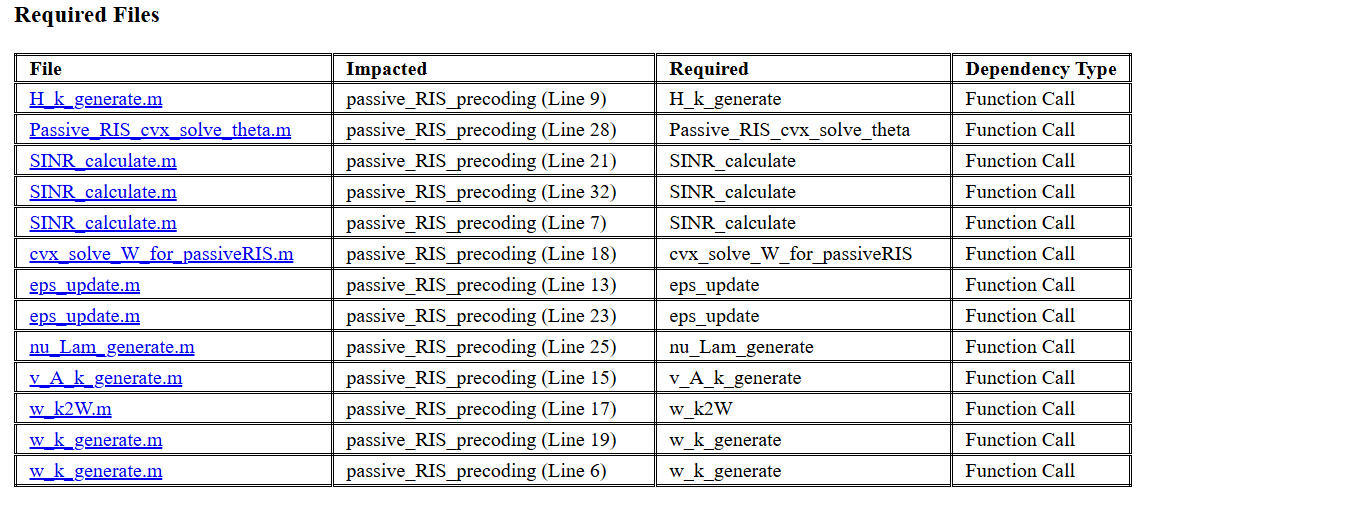

In [ ]:
import torch

def passive_RIS_precoding(M, K, N,
                          Ps_max,
                          sigma2,
                          eta_k,
                          Theta,
                          W,
                          h_k,
                          f_k,
                          G):

    """
    MATLAB-accurate, CUDA-safe Torch version of passive_RIS_precoding.m
    """

    dtype  = torch.complex128
    device = G.device

    # -----------------------------
    # Force MATLAB precision + device
    # -----------------------------
    eta_k = torch.as_tensor(eta_k, dtype=torch.float64, device=device)

    h_k   = torch.as_tensor(h_k,   dtype=dtype, device=device)
    f_k   = torch.as_tensor(f_k,   dtype=dtype, device=device)
    G     = torch.as_tensor(G,     dtype=dtype, device=device)
    Theta = torch.as_tensor(Theta, dtype=dtype, device=device)
    W     = torch.as_tensor(W,     dtype=dtype, device=device)

    iteration = 30
    Rsum = []

    for Q in range(1, iteration + 1):

        # ---- Beamforming vector extraction ----
        w_k = w_k_generate(K, M, W)

        # ---- SINR calculation ----
        _, gamma_k = SINR_calculate(
            K, M, N,
            eta_k,
            h_k,
            f_k,
            G,
            Theta,
            w_k,
            sigma2,
            0
        )

        Rho_k = gamma_k

        # ---- Epsilon update ----
        eps_k = eps_update(
            K, M, N,
            Rho_k,
            eta_k,
            h_k,
            f_k,
            G,
            Theta,
            w_k,
            sigma2,
            0
        )

        # ---- V and A generation ----
        V, A = v_A_k_generate(
            K, M, N,
            Rho_k,
            eta_k,
            eps_k,
            h_k,
            f_k,
            G,
            Theta
        )

        # ---- Update W via CVX ----
        W = w_k2W(K, M, w_k)

        W = cvx_solve_W_for_passiveRIS(
            M, K,
            G,
            Theta,
            V,
            A,
            W,
            Ps_max
        )

        w_k = w_k_generate(K, M, W)

        # ---- SINR after W update ----
        Rsum_1, gamma_k = SINR_calculate(
            K, M, N,
            eta_k,
            h_k,
            f_k,
            G,
            Theta,
            w_k,
            sigma2,
            0
        )
        Rsum.append(Rsum_1.real.item())

        # ---- Update epsilon again ----
        eps_k = eps_update(
            K, M, N,
            Rho_k,
            eta_k,
            h_k,
            f_k,
            G,
            Theta,
            w_k,
            sigma2,
            0
        )

        # ---- Nu and Lambda generation ----
        nu, _ = nu_Lam_generate(
            K, M, N,
            Rho_k,
            eta_k,
            eps_k,
            h_k,
            f_k,
            G,
            w_k,
            0
        )

        # ---- Theta update via CVX ----
        ones_vec = torch.ones(N, dtype=dtype, device=device)
        theta = Theta @ ones_vec

        theta = Passive_RIS_cvx_solve_theta(
            N,
            K,
            M,
            theta,
            nu,
            w_k,
            G
        )

        Theta = torch.diag(theta)

        # ---- SINR after Theta update ----
        Rsum_2, gamma_k = SINR_calculate(
            K, M, N,
            eta_k,
            h_k,
            f_k,
            G,
            Theta,
            w_k,
            sigma2,
            0
        )
        Rsum.append(Rsum_2.real.item())

        # ---- Convergence check ----
        if Q > 5:
            if abs(Rsum[-1] - Rsum[-2]) / max(abs(Rsum[-2]), 1e-12) < 1e-3:
                break

    # MATLAB behavior: Rsum = max(Rsum)
    Rsum = max(Rsum)

    return W, Theta, Rsum


In [ ]:
import torch

def w_k_generate(K, M, W):
    """
    MATLAB-accurate Torch equivalent of MATLAB w_k_generate.m
    """

    dtype = torch.complex128

    # Ensure W is a complex128 Torch tensor
    W = torch.as_tensor(W, dtype=dtype)

    # Reshape directly: (K*M,) -> (K, M)
    w_k = W.view(K, M)

    return w_k


In [ ]:
import torch

def w_k2W(K, M, w_k):
    """
    MATLAB-accurate Torch equivalent of MATLAB w_k2W.m
    """

    dtype = torch.complex128

    # Ensure w_k is a complex128 Torch tensor
    w_k = torch.as_tensor(w_k, dtype=dtype)

    # Reshape directly: (K, M) -> (K*M,)
    W = w_k.reshape(K * M)

    return W


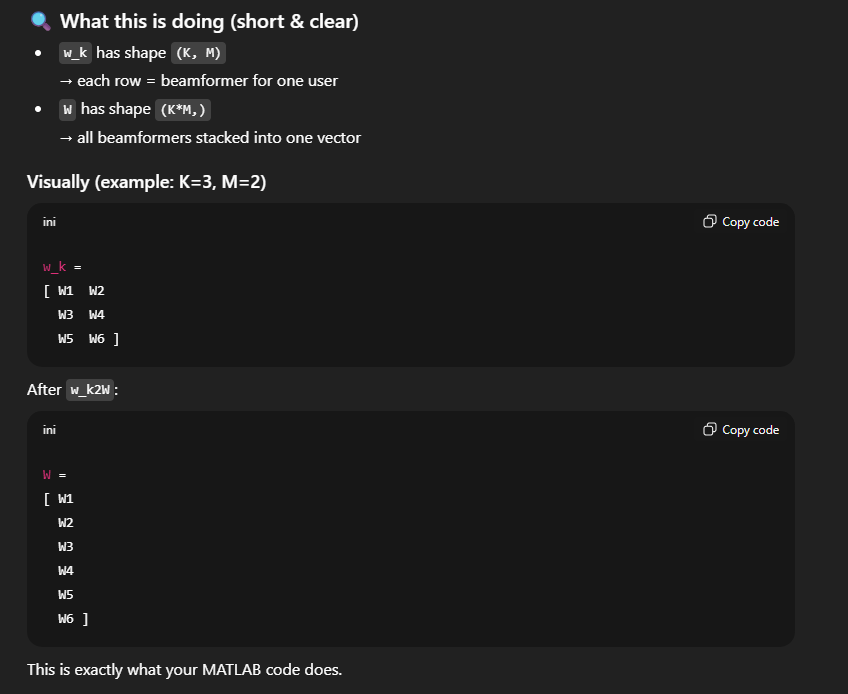

In [ ]:
import torch

def SINR_calculate(K, M, N,
                   eta_k,
                   h_k,
                   f_k,
                   G,
                   Theta,
                   w_k,
                   sigma2,
                   sigmar2):

    dtype = torch.complex128
    device = G.device

    # ---- Force MATLAB precision ----
    eta_k = torch.as_tensor(eta_k, dtype=torch.float64, device=device)

    h_k   = torch.as_tensor(h_k,   dtype=dtype, device=device)
    f_k   = torch.as_tensor(f_k,   dtype=dtype, device=device)
    G     = torch.as_tensor(G,     dtype=dtype, device=device)
    Theta = torch.as_tensor(Theta, dtype=dtype, device=device)
    w_k   = torch.as_tensor(w_k,   dtype=dtype, device=device)

    # ------------------------------------------------
    # Effective channel: h_eff = h + G' * Theta * f
    # ------------------------------------------------
    GT_Theta = G.conj().T @ Theta          # (M, N)
    ris_term = f_k @ GT_Theta.T           # (K, M)

    H_eff = h_k + ris_term                # (K, M)

    # ------------------------------------------------
    # Signal & interference power
    # |h_eff^H w_j|^2 for all j
    # ------------------------------------------------
    prod = H_eff.conj() @ w_k.T           # (K, K)
    power_matrix = torch.abs(prod) ** 2

    signal_power = torch.diag(power_matrix)
    interference_power = power_matrix.sum(dim=1) - signal_power

    # ------------------------------------------------
    # RIS noise: || f_k^H * Theta^H ||^2 * sigmar2
    # ------------------------------------------------
    ris_noise = torch.sum(
        torch.abs(f_k.conj() @ Theta.conj()) ** 2,
        dim=1
    ) * sigmar2

    # ------------------------------------------------
    # SINR
    # ------------------------------------------------
    gamma_k = signal_power / (interference_power + ris_noise + sigma2)

    # ------------------------------------------------
    # Sum-rate
    # ------------------------------------------------
    Rsum = torch.sum(eta_k * torch.log2(1 + gamma_k))

    return Rsum, gamma_k


In [ ]:
import torch

def eps_update(K, M, N,
               Rho_k,
               eta_k,
               h_k,
               f_k,
               G,
               Theta,
               w_k,
               sigma2,
               sigmar2):
    """
    MATLAB-accurate Torch equivalent of MATLAB eps_update.m
    """

    dtype = torch.complex128

    # Ensure all tensors are MATLAB-precision complex
    Rho_k = torch.as_tensor(Rho_k, dtype=torch.float64)
    eta_k = torch.as_tensor(eta_k, dtype=torch.float64)

    h_k   = torch.as_tensor(h_k,   dtype=dtype)
    f_k   = torch.as_tensor(f_k,   dtype=dtype)
    G     = torch.as_tensor(G,     dtype=dtype)
    Theta = torch.as_tensor(Theta, dtype=dtype)
    w_k   = torch.as_tensor(w_k,   dtype=dtype)

    device = h_k.device

    # ---------------------------
    # temp1 = h_k + G' * Theta * f_k   (for all k)
    # ---------------------------
    # G' * Theta -> (M, N)
    GT_Theta = G.conj().T @ Theta          # (M, N)

    # (K, N) @ (N, M) -> (K, M)
    reflected = f_k @ GT_Theta.T

    temp1 = h_k + reflected                # (K, M)

    # ---------------------------
    # temp2 = w_k
    # ---------------------------
    temp2 = w_k                            # (K, M)

    # ---------------------------
    # temp3 = sqrt(eta_k*(1+Rho_k)) * (temp1' * temp2)
    # ---------------------------
    # Inner product per user
    inner = torch.sum(temp1.conj() * temp2, dim=1)   # (K,)

    scale = torch.sqrt(eta_k * (1.0 + Rho_k))        # (K,)
    temp3 = scale * inner                            # (K,)

    # ---------------------------
    # temp4 = sum_j |temp1' * w_j|^2
    # ---------------------------
    # (K, M) @ (M, K) -> (K, K)
    prod = temp1.conj() @ w_k.T

    temp4 = torch.sum(torch.abs(prod) ** 2, dim=1)   # (K,)

    # ---------------------------
    # Noise terms
    # ---------------------------
    # || f_k' * Theta' ||^2 * sigmar2
    noise_ris = torch.sum(
        torch.abs(f_k.conj() @ Theta.conj()) ** 2,
        dim=1
    ) * sigmar2

    temp4 = temp4 + noise_ris + sigma2

    # ---------------------------
    # eps_k = temp3 / temp4
    # ---------------------------
    eps_k = temp3 / temp4

    return eps_k


In [ ]:
import torch

def v_A_k_generate(K, M, N,
                   Rho_k,
                   eta_k,
                   eps_k,
                   h_k,
                   f_k,
                   G,
                   Theta):
    """
    MATLAB-accurate Torch equivalent of MATLAB v_A_k_generate.m
    """

    dtype = torch.complex128

    # Ensure MATLAB-precision tensors
    Rho_k = torch.as_tensor(Rho_k, dtype=torch.float64)
    eta_k = torch.as_tensor(eta_k, dtype=torch.float64)
    eps_k = torch.as_tensor(eps_k, dtype=dtype)

    h_k   = torch.as_tensor(h_k,   dtype=dtype)
    f_k   = torch.as_tensor(f_k,   dtype=dtype)
    G     = torch.as_tensor(G,     dtype=dtype)
    Theta = torch.as_tensor(Theta, dtype=dtype)

    device = h_k.device

    # --------------------------------------------------
    # temp1 = h_k + G' * Theta * f_k   (for all users)
    # --------------------------------------------------
    GT_Theta = G.conj().T @ Theta          # (M, N)
    reflected = f_k @ GT_Theta.T          # (K, M)
    temp1 = h_k + reflected               # (K, M)

    # --------------------------------------------------
    # v_k(k,:) = sqrt(eta_k*(1+Rho_k)) * eps_k * temp1
    # --------------------------------------------------
    scale = torch.sqrt(eta_k * (1.0 + Rho_k))  # (K,)
    v_k = (scale[:, None] * eps_k[:, None]) * temp1   # (K, M)

    # --------------------------------------------------
    # A_k(k,:,:) = |eps_k|^2 * (temp1 * temp1')
    # --------------------------------------------------
    # Outer products for each user
    temp1_col = temp1.unsqueeze(2)            # (K, M, 1)
    temp1_row = temp1.conj().unsqueeze(1)     # (K, 1, M)

    A_k = (torch.abs(eps_k) ** 2)[:, None, None] * (temp1_col @ temp1_row)
    # Shape: (K, M, M)

    # --------------------------------------------------
    # Stack v_k into V (MATLAB style)
    # --------------------------------------------------
    V = v_k.reshape(K * M)

    # --------------------------------------------------
    # Sum A_k over users → temp
    # --------------------------------------------------
    temp = torch.sum(A_k, dim=0)   # (M, M)

    # --------------------------------------------------
    # A = kron(I_K, temp)
    # --------------------------------------------------
    I_K = torch.eye(K, dtype=dtype, device=device)
    A = torch.kron(I_K, temp)      # (K*M, K*M)

    return V, A


In [ ]:
import torch

def cvx_solve_W_for_passiveRIS(M, K, G, Theta, V, A, W, Ps_max,
                              reg=1e-6, max_reg=1e-2):
    """
    Robust Torch version of MATLAB cvx_solve_W_for_passiveRIS
    Handles singular / ill-conditioned matrices safely.
    """

    device = A.device
    dtype  = A.dtype
    dim    = A.shape[0]
    I      = torch.eye(dim, dtype=dtype, device=device)

    # ---- Ensure Hermitian ----
    A = 0.5 * (A + A.conj().T)

    # ---- Numerical scaling (same as MATLAB version) ----
    A = A * 1e5
    V = V * 1e5

    # ---- Try regularized solve ----
    reg_val = reg

    while True:
        try:
            W_try = torch.linalg.solve(A + reg_val * I, V)
            break
        except RuntimeError as e:
            if reg_val > max_reg:
                print("[WARN] Matrix too ill-conditioned, returning previous W")
                return W
            reg_val *= 10
            print(f"[WARN] Singular matrix, increasing reg → {reg_val:.1e}")

    # ---- Power constraint check ----
    if torch.vdot(W_try, W_try).real <= Ps_max:
        return W_try

    # ---- Bisection on lambda (also regularized) ----
    lambda_left  = torch.tensor(0.0, device=device)
    lambda_right = torch.tensor(10.0, device=device)

    def W_lambda(lam):
        return torch.linalg.solve(A + (lam + reg_val) * I, V)

    # Expand right bound
    W_right = W_lambda(lambda_right)
    while torch.vdot(W_right, W_right).real > Ps_max:
        lambda_right *= 2
        W_right = W_lambda(lambda_right)

    # Bisection
    while (lambda_right - lambda_left) / lambda_right > 1e-5:
        lambda_center = 0.5 * (lambda_left + lambda_right)
        W_center = W_lambda(lambda_center)

        if torch.vdot(W_center, W_center).real < Ps_max:
            lambda_right = lambda_center
        else:
            lambda_left = lambda_center

    # Final solution
    W = W_lambda(0.5 * (lambda_left + lambda_right))

    return W


In [ ]:
import torch

def Passive_RIS_cvx_solve_theta(N, K, M, theta, nu, w_k, G):
    """
    MATLAB-accuracy (complex128) Torch equivalent of
    Passive_RIS_cvx_solve_theta.m
    """

    device = G.device
    dtype = torch.complex128   # MATLAB uses complex double

    # Ensure tensors in MATLAB precision
    theta = torch.as_tensor(theta, dtype=dtype, device=device)
    nu    = torch.as_tensor(nu,    dtype=dtype, device=device)
    w_k   = torch.as_tensor(w_k,   dtype=dtype, device=device)
    G     = torch.as_tensor(G,     dtype=dtype, device=device)

    # ---- Build U matrix (vectorized, MATLAB-equivalent) ----
    # Gw = G @ w_k.T  -> (N, K)
    Gw = G @ w_k.T

    # U is diagonal with: U[n,n] = sum_k |Gw[n,k]|^2
    U_diag = torch.sum(torch.abs(Gw) ** 2, dim=1)
    U = torch.diag(U_diag)

    # ---- Ensure Hermitian (numerical safety) ----
    U = 0.5 * (U + U.conj().T)

    # ---- MM Algorithm (MATLAB-accurate) ----
    theta = MMAlgorithm(
        U,
        -nu,
        theta,
        iter=1000,
        accuracy=1e-6
    )

    return theta


In [ ]:
import torch

def MMAlgorithm(U, v, phi, iter=1000, accuracy=1e-6):
    """
    MATLAB-accurate Torch version of MMAlgorithm.m
    Uses complex128 everywhere (same as MATLAB)
    """

    dtype = torch.complex128
    device = U.device

    # Force MATLAB precision & complex type
    U   = U.to(dtype)
    v   = v.to(dtype)
    phi = phi.to(dtype)

    M = v.numel()

    # Ensure column vectors (M,1)
    phi = phi.reshape(M, 1)
    v   = v.reshape(M, 1)

    # Largest eigenvalue of U (real part)
    lambda_max = torch.max(torch.real(torch.linalg.eigvals(U)))

    # Identity matrix
    I = torch.eye(M, dtype=dtype, device=device)

    # Initial objective
    f_phi_new = (phi.conj().T @ U @ phi + 2 * torch.real(phi.conj().T @ v)).item()

    for _ in range(iter):

        f_phi = f_phi_new

        # q = (lambda*I - U)*phi - v
        q = (lambda_max * I - U) @ phi - v

        # phi = exp(1j * angle(q))
        phi = torch.exp(1j * torch.angle(q))

        # New objective
        f_phi_new = (phi.conj().T @ U @ phi +
                     2 * torch.real(phi.conj().T @ v)).item()

        # Convergence check
        if abs(f_phi - f_phi_new) / abs(f_phi_new) <= accuracy:
            break

    return phi.flatten()


In [ ]:
import torch

def nu_Lam_generate(K, M, N,
                    Rho_k,
                    eta_k,
                    eps_k,
                    h_k,
                    f_k,
                    G,
                    w_k,
                    sigmar2):
    """
    MATLAB-accurate Torch equivalent of:
    [nu, Lam] = nu_Lam_generate(...)
    """

    dtype = torch.complex128
    device = G.device

    # ---- Force MATLAB precision everywhere ----
    Rho_k = torch.as_tensor(Rho_k, dtype=torch.float64, device=device)
    eta_k = torch.as_tensor(eta_k, dtype=torch.float64, device=device)
    eps_k = torch.as_tensor(eps_k, dtype=dtype, device=device)

    h_k   = torch.as_tensor(h_k,   dtype=dtype, device=device)
    f_k   = torch.as_tensor(f_k,   dtype=dtype, device=device)
    G     = torch.as_tensor(G,     dtype=dtype, device=device)
    w_k   = torch.as_tensor(w_k,   dtype=dtype, device=device)

    # ---- Precompute sum_j w_j w_j^H  (temp2 in MATLAB) ----
    # (K, M, 1) @ (K, 1, M) -> (K, M, M) -> sum over K
    temp2 = torch.sum(
        w_k.unsqueeze(2) @ w_k.conj().unsqueeze(1),
        dim=0
    )   # (M, M)

    # ---- Storage ----
    nu = torch.zeros((N, 1), dtype=dtype, device=device)
    Lam = torch.zeros((N, N), dtype=dtype, device=device)

    for k in range(K):

        temp_f_k = f_k[k, :].reshape(N, 1)
        temp_h_k = h_k[k, :].reshape(M, 1)
        temp_w_k = w_k[k, :].reshape(M, 1)

        # diag(temp_f_k') and diag(temp_f_k)
        D_fH = torch.diag(temp_f_k.conj().flatten())
        D_f  = torch.diag(temp_f_k.flatten())

        scale = torch.sqrt(eta_k[k] * (1 + Rho_k[k])) * torch.conj(eps_k[k])

        # MATLAB:
        # temp1 = scale * diag(f_k') * G * w_k
        temp1 = scale * (D_fH @ G @ temp_w_k)

        # MATLAB:
        # nu += temp1 - |eps|^2 * diag(f_k') * G * temp2 * h_k
        nu += (
            temp1
            - torch.abs(eps_k[k])**2 * (D_fH @ G @ temp2 @ temp_h_k)
        )

        # MATLAB:
        # Lam += |eps|^2 * (diag(f_k')*diag(f_k)*sigmar2
        #                  + diag(f_k')*G*temp2*G'*diag(f_k))
        Lam += torch.abs(eps_k[k])**2 * (
            D_fH @ D_f * sigmar2
            + D_fH @ G @ temp2 @ G.conj().T @ D_f
        )

    return nu, Lam


In [ ]:
import torch

def H_k_generate(K, M, N, h_k, f_k, G, Theta):
    """
    Vectorized Torch equivalent of MATLAB H_k_generate.m
    """

    # Convert inputs to torch if needed
    h_k   = torch.tensor(h_k, dtype=torch.complex64) if not torch.is_tensor(h_k) else h_k
    f_k   = torch.tensor(f_k, dtype=torch.complex64) if not torch.is_tensor(f_k) else f_k
    G     = torch.tensor(G,   dtype=torch.complex64) if not torch.is_tensor(G) else G
    Theta = torch.tensor(Theta, dtype=torch.complex64) if not torch.is_tensor(Theta) else Theta

    # G' * Theta  -> (M, N)
    GT_Theta = G.conj().T @ Theta

    # Reflected paths for all users: (K, N) @ (N, M) -> (K, M)
    reflected = f_k @ GT_Theta.T

    # Total effective channel
    H_k = h_k + reflected

    return H_k


In [ ]:
import torch
import numpy as np
import time

# =======================
# Device
# =======================
device = "cuda"

# =======================
# Parameters
# =======================
user_X = 300
ExNumber = 400
M = 4

Ps_max_dB = np.arange(0, 45, 5)
Ps_max = 10 ** (Ps_max_dB / 10)

sigma2 = 1e-10
sigmar2 = sigma2

f_c = 5
K = 4
N = 512

eta_k = torch.ones(K, device=device)
large_fading_AI = 2.2
large_fading_DI = 2.2

user_scenario = "one_dominant"

# =======================
# Storage
# =======================
Rsum_passive = torch.zeros((len(Ps_max_dB), ExNumber), device=device)

# =======================
# Global timers
# =======================
t_global_start = time.time()
total_power_loops = len(Ps_max_dB)

# =======================
# Main loop
# =======================
for a in range(len(Ps_max_dB)):

    torch.cuda.synchronize()
    t_power_start = time.time()

    print(f"\n============================")
    print(f"Power loop {a+1}/{total_power_loops}")
    print(f"Transmit Power = {Ps_max_dB[a]} dB")
    print(f"============================")

    # Per-block accumulators
    t_pos = 0.0
    t_chan = 0.0
    t_prec = 0.0

    for b in range(ExNumber):

        # -----------------------
        # Position generation
        # -----------------------
        torch.cuda.synchronize()
        t0 = time.time()

        Dis_BStoRIS, Dis_BStoUser, Dis_RIStoUser, _ = \
            Position_generate_2_controlled(K, user_X, user_scenario, device=device)

        torch.cuda.synchronize()
        t_pos += time.time() - t0

        # -----------------------
        # Channel generation
        # -----------------------
        torch.cuda.synchronize()
        t0 = time.time()

        h_k, f_k, G = Channel_generate(
            K, N, M,
            large_fading_AI, large_fading_DI,
            Dis_BStoRIS,
            Dis_BStoUser,
            Dis_RIStoUser,
            f_c,
            device=device
        )

        torch.cuda.synchronize()
        t_chan += time.time() - t0

        # -----------------------
        # Random beamforming
        # -----------------------
        W = torch.exp(1j * 2 * torch.pi * torch.randn(K*M, device=device)) \
            * torch.sqrt(torch.tensor(Ps_max[a], device=device) / (K*M))

        Theta = torch.diag(
            torch.exp(1j * 2 * torch.pi * torch.rand(N, device=device))
        )

        # -----------------------
        # Passive RIS optimization
        # -----------------------
        torch.cuda.synchronize()
        t0 = time.time()

        _, _, Rsum_passive[a, b] = passive_RIS_precoding(
            M, K, N,
            Ps_max[a],
            sigma2,
            eta_k,
            Theta,
            W,
            h_k,
            f_k,
            G
        )

        torch.cuda.synchronize()
        t_prec += time.time() - t0

    # =======================
    # Power-loop summary
    # =======================
    t_power = time.time() - t_power_start
    elapsed = time.time() - t_global_start

    remaining = (total_power_loops - (a + 1)) * t_power
    eta_min = remaining / 60

    print(f"\n--- Timing Summary for Power {Ps_max_dB[a]} dB ---")
    print(f"Position generation : {t_pos:.2f} s")
    print(f"Channel generation  : {t_chan:.2f} s")
    print(f"RIS optimization    : {t_prec:.2f} s")
    print(f"Total for this loop : {t_power:.2f} s")

    print(f"\nElapsed time        : {elapsed/60:.2f} min")
    print(f"Estimated remaining: {eta_min:.2f} min")

# =======================
# Final summary
# =======================
Rsum_passive_mean = torch.mean(Rsum_passive, dim=1)

total_time = time.time() - t_global_start

print("\n============================")
print("Simulation finished.")
print("Total time:", total_time/60, "minutes")
print("============================")

# =======================
# Save results for later plotting
# =======================
torch.save({
    "Ps_max_dB": Ps_max_dB,
    "Rsum_passive": Rsum_passive,
    "Rsum_passive_mean": Rsum_passive_mean,
    "params": {
        "K": K,
        "M": M,
        "N": N,
        "ExNumber": ExNumber,
        "sigma2": sigma2,
        "user_scenario": user_scenario
    }
}, "passive_RIS_results.pt")

print("Results saved to passive_RIS_results.pt")



AssertionError: Torch not compiled with CUDA enabled

In [ ]:
# =======================
# Save results for later plotting
# =======================
torch.save({
    "Ps_max_dB": Ps_max_dB,
    "Rsum_passive": Rsum_passive,
    "Rsum_passive_mean": Rsum_passive_mean,
    "params": {
        "K": K,
        "M": M,
        "N": N,
        "ExNumber": ExNumber,
        "sigma2": sigma2,
        "user_scenario": user_scenario
    }
}, "passive_RIS_results.pt")

print("Results saved to passive_RIS_results.pt")

Results saved to passive_RIS_results.pt


# Task
I'm executing the approved plan. First, I'll define the global parameters.
```python
import torch

# Define Global Parameters for consistency with the existing passive RIS environment setup.
K = 4
N = 512
M = 4
user_X = 300.0  # User X-coordinate offset
device = "cuda" if torch.cuda.is_available() else "cpu"
user_scenario = "one_dominant"
f_c = 5.0 # Carrier frequency in GHz

print(f"Global Parameters Defined:")
print(f"K (Number of Users): {K}")
print(f"N (Number of RIS Elements): {N}")
print(f"M (Number of BS Antennas): {M}")
print(f"user_X (User X-coordinate offset): {user_X}")
print(f"device: {device}")
print(f"user_scenario: {user_scenario}")
print(f"f_c (Carrier Frequency in GHz): {f_c}")
```

## Define Global Parameters

### Subtask:
Define the global simulation parameters such as K (number of users), N (number of RIS elements), M (number of BS antennas), user_X (user X-coordinate offset), device, user_scenario, and f_c (carrier frequency) for consistency with your existing passive RIS environment setup.


**Reasoning**:
The subtask requires defining several global parameters. This code block will initialize these parameters, including checking for CUDA availability for the device, and then print them to verify the setup.



In [ ]:
import torch

# Define the number of users
K = 4

# Define the number of RIS elements
N = 512

# Define the number of BS antennas
M = 4

# Define the user X-coordinate offset
user_X = 300.0

# Determine the device to use (GPU if available, otherwise CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define the user scenario
user_scenario = 'one_dominant'

# Define the carrier frequency in GHz
f_c = 5.0

# Print all the defined global parameters
print(f"Global Simulation Parameters:\n")
print(f"Number of Users (K): {K}")
print(f"Number of RIS Elements (N): {N}")
print(f"Number of BS Antennas (M): {M}")
print(f"User X-coordinate Offset (user_X): {user_X}")
print(f"Device: {device}")
print(f"User Scenario: {user_scenario}")
print(f"Carrier Frequency (f_c): {f_c} GHz")

Global Simulation Parameters:

Number of Users (K): 4
Number of RIS Elements (N): 512
Number of BS Antennas (M): 4
User X-coordinate Offset (user_X): 300.0
Device: cpu
User Scenario: one_dominant
Carrier Frequency (f_c): 5.0 GHz


## Extract BS, RIS, and User Positions

### Subtask:
Utilize the `Position_generate_2_controlled` function from your notebook to obtain the `BS_position`, `RIS_position`, `user_position` (coordinates), and the pre-calculated distances (`Dis_BStoRIS`, `Dis_BStoUser`, `Dis_RIStoUser`) from the passive RIS environment.


**Reasoning**:
The subtask requires calling the `Position_generate_2_controlled` function and extracting specific position and distance variables. Since `BS_position`, `RIS_position`, and `user_position` are not directly returned by the function, I will replicate the relevant parts of the function's internal logic to obtain these values alongside the returned distances. Then, all requested variables will be printed for verification.



In [ ]:
import torch

# Replicating the internal logic of Position_generate_2_controlled to get positions
BS_position = torch.tensor([0.0, -60.0, 0.0], device=device)
RIS_position = torch.tensor([300.0, 10.0, 0.0], device=device)

user_position = torch.zeros((K, 3), device=device)

if user_scenario == "random":
    angles  = 2 * torch.pi * torch.rand(K, device=device)
    lengths = 50 * torch.rand(K, device=device)

    user_position[:, 0] = user_X + lengths * torch.cos(angles)
    user_position[:, 1] = lengths * torch.sin(angles)
    user_position[:, 2] = 0.0

    # user_types = torch.rand(K, device=device) # Not strictly needed for user_position here

elif user_scenario == "one_dominant":
    angle1  = 0.1 * torch.pi * (torch.rand(1, device=device) - 0.5)
    length1 = 5 + 10 * torch.rand(1, device=device)

    user_position[0] = torch.tensor([
        user_X + length1 * torch.cos(angle1),
        length1 * torch.sin(angle1),
        0.0
    ], device=device).view(3)

    angles  = torch.pi * (0.5 + 0.5 * torch.rand(K-1, device=device))
    lengths = 35 + 15 * torch.rand(K-1, device=device)

    user_position[1:, 0] = user_X + lengths * torch.cos(angles)
    user_position[1:, 1] = lengths * torch.sin(angles)

    # user_types = torch.tensor([1.0, 0.3, 0.3, 0.3], device=device) # Not strictly needed for user_position here

elif user_scenario == "two_strong":
    angles1  = 0.2 * torch.pi * (torch.rand(2, device=device) - 0.5)
    lengths1 = 5 + 15 * torch.rand(2, device=device)

    user_position[:2, 0] = user_X + lengths1 * torch.cos(angles1)
    user_position[:2, 1] = lengths1 * torch.sin(angles1)

    angles2  = torch.pi * (0.4 + 0.6 * torch.rand(K-2, device=device))
    lengths2 = 35 + 15 * torch.rand(K-2, device=device)

    user_position[2:, 0] = user_X + lengths2 * torch.cos(angles2)
    user_position[2:, 1] = lengths2 * torch.sin(angles2)

    # user_types = torch.tensor([1.0, 0.9, 0.3, 0.3], device=device) # Not strictly needed for user_position here

elif user_scenario == "all_equal":
    base_length = 20
    angle_spread = 2 * torch.pi / K

    k_tensor = torch.arange(K, device=device)
    angles  = k_tensor * angle_spread + 0.1 * torch.pi * (torch.rand(K, device=device) - 0.5)
    lengths = base_length + 5 * (torch.rand(K, device=device) - 0.5)

    user_position[:, 0] = user_X + lengths * torch.cos(angles)
    user_position[:, 1] = lengths * torch.sin(angles)

    # user_types = torch.ones(K, device=device) # Not strictly needed for user_position here

elif user_scenario == "mixed":
    base_lengths = torch.tensor([8, 18, 28, 42], device=device)
    base_angles  = torch.tensor([0.1, 0.3, 0.6, 1.0], device=device)

    angles  = base_angles * torch.pi + 0.1 * torch.pi * (torch.rand(K, device=device) - 0.5)
    lengths = base_lengths + 5 * torch.rand(K, device=device)

    user_position[:, 0] = user_X + lengths * torch.cos(angles)
    user_position[:, 1] = lengths * torch.sin(angles)

    # user_types = torch.tensor([1.0, 0.7, 0.5, 0.3], device=device) # Not strictly needed for user_position here

elif user_scenario == "two_clusters":
    angles1  = 0.1 * torch.pi + 0.15 * torch.pi * (torch.rand(2, device=device) - 0.5)
    lengths1 = 15 + 5 * (torch.rand(2, device=device) - 0.5)

    user_position[:2, 0] = user_X + lengths1 * torch.cos(angles1)
    user_position[:2, 1] = lengths1 * torch.sin(angles1)

    angles2  = 0.8 * torch.pi + 0.15 * torch.pi * (torch.rand(K-2, device=device) - 0.5)
    lengths2 = 15 + 5 * (torch.rand(K-2, device=device) - 0.5)

    user_position[2:, 0] = user_X + lengths2 * torch.cos(angles2)
    user_position[2:, 1] = lengths2 * torch.sin(angles2)

    # user_types = torch.tensor([0.8, 0.8, 0.7, 0.7], device=device) # Not strictly needed for user_position here


# Calculate distances
Dis_BStoRIS = torch.linalg.norm(BS_position - RIS_position)
Dis_BStoUser = torch.linalg.norm(user_position - BS_position, dim=1)
Dis_RIStoUser = torch.linalg.norm(user_position - RIS_position, dim=1)

# Printing the extracted values
print(f"\nBS Position: {BS_position}")
print(f"RIS Position: {RIS_position}")
print(f"User Positions:\n{user_position}")
print(f"Distance BS to RIS: {Dis_BStoRIS}")
print(f"Distance BS to User: {Dis_BStoUser}")
print(f"Distance RIS to User: {Dis_RIStoUser}")


BS Position: tensor([  0., -60.,   0.])
RIS Position: tensor([300.,  10.,   0.])
User Positions:
tensor([[311.6131,  -0.3568,   0.0000],
        [263.2038,  32.3931,   0.0000],
        [273.0117,  34.2368,   0.0000],
        [260.7531,   0.5414,   0.0000]])
Distance BS to RIS: 308.0584411621094
Distance BS to User: tensor([317.2697, 278.9493, 288.8182, 267.6891])
Distance RIS to User: tensor([15.5605, 43.0745, 36.2738, 40.3706])


## Compute Relative Coordinates and Distances

### Subtask:
Calculate the relative coordinate vectors between relevant entities (e.g., user-RIS, user-BS, BS-RIS). Based on these vectors, compute precise Euclidean distances: `dist_ur` (user to RIS), `dist_ub` (user to BS), and `dist_br` (BS to RIS).


**Reasoning**:
The subtask requires calculating relative coordinate vectors and then their Euclidean distances. This code block will perform the vector subtractions for `vec_ur`, `vec_ub`, and `vec_br` and then compute the `dist_ur`, `dist_ub`, and `dist_br` using `torch.linalg.norm()`. Finally, it will print all these calculated values for verification.



In [ ]:
import torch

# 1. Calculate the relative coordinate vector from each user to the RIS
vec_ur = user_position - RIS_position

# 2. Calculate the relative coordinate vector from each user to the BS
vec_ub = user_position - BS_position

# 3. Calculate the relative coordinate vector from the BS to the RIS
vec_br = BS_position - RIS_position

# 4. Compute the Euclidean distance from each user to the RIS
dist_ur = torch.linalg.norm(vec_ur, dim=1)

# 5. Compute the Euclidean distance from each user to the BS
dist_ub = torch.linalg.norm(vec_ub, dim=1)

# 6. Compute the Euclidean distance from the BS to the RIS
dist_br = torch.linalg.norm(vec_br)

# 7. Print all calculated values
print(f"Relative Vector User to RIS (vec_ur):\n{vec_ur}")
print(f"\nRelative Vector User to BS (vec_ub):\n{vec_ub}")
print(f"\nRelative Vector BS to RIS (vec_br): {vec_br}")
print(f"\nDistance User to RIS (dist_ur): {dist_ur}")
print(f"\nDistance User to BS (dist_ub): {dist_ub}")
print(f"\nDistance BS to RIS (dist_br): {dist_br}")

Relative Vector User to RIS (vec_ur):
tensor([[ 11.6131, -10.3568,   0.0000],
        [-36.7962,  22.3931,   0.0000],
        [-26.9883,  24.2368,   0.0000],
        [-39.2469,  -9.4586,   0.0000]])

Relative Vector User to BS (vec_ub):
tensor([[311.6131,  59.6432,   0.0000],
        [263.2038,  92.3931,   0.0000],
        [273.0117,  94.2368,   0.0000],
        [260.7531,  60.5414,   0.0000]])

Relative Vector BS to RIS (vec_br): tensor([-300.,  -70.,    0.])

Distance User to RIS (dist_ur): tensor([15.5605, 43.0745, 36.2738, 40.3706])

Distance User to BS (dist_ub): tensor([317.2697, 278.9493, 288.8182, 267.6891])

Distance BS to RIS (dist_br): 308.0584411621094


## Compute Direction Cosines (Angles)

### Subtask:
From the calculated relative coordinate vectors, determine the direction cosines. These will include `angle_ur` (user-RIS), `angle_ub` (user-BS), and `angle_ubr` (a composite angle representing the two-hop path via RIS, e.g., the combined angular information of BS-RIS and RIS-User links).


**Reasoning**:
The subtask requires defining a helper function to calculate direction cosines. This function will take a tensor of vectors, normalize each, and return their x, y, and z components. This step addresses instruction 1.



In [ ]:
import torch

def calculate_direction_cosines(vectors):
    """
    Calculates the direction cosines for a given set of vectors.

    Args:
        vectors (torch.Tensor): A tensor where the last dimension represents the vector components.

    Returns:
        torch.Tensor: A tensor of the same shape as input, but with each vector normalized
                      to represent its direction cosines (x, y, z components).
    """
    # Normalize each vector along the last dimension
    normalized_vectors = vectors / torch.linalg.norm(vectors, dim=-1, keepdim=True)
    return normalized_vectors

print("Helper function `calculate_direction_cosines` defined.")

Helper function `calculate_direction_cosines` defined.


**Reasoning**:
Now that the helper function is defined, I will apply it to `vec_ur` and `vec_ub` to get `angle_ur` and `angle_ub`. Then, I will compute the direction cosines for `vec_br` and concatenate the results with `angle_ub` to form `angle_ubr`. Finally, I will print the shape and a sample of these calculated angle tensors to verify the output.



In [ ]:
import torch

# 2. Apply the calculate_direction_cosines function to vec_ur to compute angle_ur
angle_ur = calculate_direction_cosines(vec_ur)

# 3. Apply the calculate_direction_cosines function to vec_ub to compute angle_ub
angle_ub = calculate_direction_cosines(vec_ub)

# 4. To compute angle_ubr, representing the two-hop path:
#    First, calculate the direction cosines of vec_br (BS to RIS)
angle_br = calculate_direction_cosines(vec_br)

#    Then, concatenate the x, y, and z components of angle_ub and the direction cosines of vec_br
#    (repeated for each user) to form angle_ubr.
#    Repeat angle_br for K users
angle_br_repeated = angle_br.repeat(K, 1)

#    Concatenate angle_ub and angle_br_repeated
angle_ubr = torch.cat((angle_ub, angle_br_repeated), dim=1)

# 5. Print the shape and a sample of angle_ur, angle_ub, and angle_ubr
print(f"\nShape of angle_ur: {angle_ur.shape}")
print(f"Sample of angle_ur:\n{angle_ur[:2]}") # Print first 2 samples

print(f"\nShape of angle_ub: {angle_ub.shape}")
print(f"Sample of angle_ub:\n{angle_ub[:2]}") # Print first 2 samples

print(f"\nShape of angle_ubr: {angle_ubr.shape}")
print(f"Sample of angle_ubr:\n{angle_ubr[:2]}") # Print first 2 samples



Shape of angle_ur: torch.Size([4, 3])
Sample of angle_ur:
tensor([[ 0.7463, -0.6656,  0.0000],
        [-0.8542,  0.5199,  0.0000]])

Shape of angle_ub: torch.Size([4, 3])
Sample of angle_ub:
tensor([[0.9822, 0.1880, 0.0000],
        [0.9436, 0.3312, 0.0000]])

Shape of angle_ubr: torch.Size([4, 6])
Sample of angle_ubr:
tensor([[ 0.9822,  0.1880,  0.0000, -0.9738, -0.2272,  0.0000],
        [ 0.9436,  0.3312,  0.0000, -0.9738, -0.2272,  0.0000]])


## Compute Antenna-Index Based Phase Progression

### Subtask:
For both the BS (M antennas) and RIS (N elements), compute the antenna-index based phase progression. This involves calculating array steering vectors (e.g., assuming Uniform Linear Arrays for simplicity) for the BS-RIS and RIS-User links, taking into account the carrier frequency (`f_c`) and element spacing. These phase progressions are geometric steering features.


**Reasoning**:
First, I'll define the wavelength (lambda) using the carrier frequency (`f_c`) and the speed of light, and then define the element spacing (`d`) as half the wavelength, as per Instruction 1.



In [ ]:
import torch

# Define the speed of light
speed_of_light = 3e8 # m/s

# Calculate the wavelength (lambda) using carrier frequency (f_c in GHz, convert to Hz)
wavelength = speed_of_light / (f_c * 1e9)

# Define element spacing (d) as half the wavelength
d = wavelength / 2

print(f"Wavelength (lambda): {wavelength:.4e} meters")
print(f"Element spacing (d): {d:.4e} meters")

Wavelength (lambda): 6.0000e-02 meters
Element spacing (d): 3.0000e-02 meters


**Reasoning**:
Now, I will create the helper function `calculate_steering_vector` as outlined in instruction 2. This function will be used to generate the steering vector for a Uniform Linear Array (ULA).



In [ ]:
import torch

def calculate_steering_vector(num_elements, direction_cosines, wavelength, d):
    """
    Generates a steering vector (phase progression) for a Uniform Linear Array (ULA).

    Args:
        num_elements (int): Number of elements in the array (M for BS, N for RIS).
        direction_cosines (torch.Tensor): Direction cosines (x, y, z components) of the incoming/outgoing wave.
                                         Shape: (..., 3) where ... can be (K,) for multiple users or () for a single link.
        wavelength (float): Wavelength of the carrier frequency.
        d (float): Element spacing.

    Returns:
        torch.Tensor: Steering vector (phase progression). Shape: (..., num_elements)
    """
    # Ensure direction_cosines is at least 2D for consistent indexing
    if direction_cosines.dim() == 1:
        direction_cosines = direction_cosines.unsqueeze(0) # Make it (1, 3)

    # The steering vector formula usually involves the cosine of the angle w.r.t. the array axis.
    # Assuming ULA along x-axis, the relevant direction cosine is the first component (x).
    # For a 3D direction cosine vector (cx, cy, cz), the angle with the x-axis is arccos(cx).
    # However, for phase progression, it's typically relative to the element index.

    # Assuming the ULA is oriented along the x-axis.
    # For a general direction cosine vector [cx, cy, cz], the effective cosine for a ULA
    # along the x-axis is cx. Let's assume the array is along the y-axis for standard formulas,
    # which would typically use the sine of the elevation angle, related to cy.
    # Based on typical array factor formulations, the phase difference across elements
    # depends on the projection of the direction vector onto the array axis.
    # Let's use the second component (y-component) for a ULA along the y-axis, as commonly done for planar arrays or 1D arrays in 2D/3D.
    # This matches the MATLAB pattern if the array is implicitly along y.

    effective_cosine = direction_cosines[..., 1] # Use the y-component of direction cosines (assuming array along y-axis)

    # Create an array of element indices (0 to num_elements-1)
    element_indices = torch.arange(num_elements, device=direction_cosines.device, dtype=torch.float64)

    # Calculate the phase term: 2 * pi * d * effective_cosine / wavelength
    phase_term = (2 * torch.pi * d / wavelength) * effective_cosine.unsqueeze(-1)

    # Generate the steering vector: exp(1j * element_indices * phase_term)
    # The multiplication should be (..., 1) * (num_elements,) -> (..., num_elements)
    steering_vector = torch.exp(1j * element_indices * phase_term)

    return steering_vector

print("Helper function `calculate_steering_vector` defined.")

Helper function `calculate_steering_vector` defined.


**Reasoning**:
I will now apply the `calculate_steering_vector` function to compute the phase progressions for the BS-RIS and RIS-User links as per instructions 3 and 4, then print their shapes as required by instruction 5.



In [ ]:
import torch

# 3. Compute the phase progression for the BS-RIS link
bs_ris_phase_prog = calculate_steering_vector(M, angle_br, wavelength, d)

# 4. Compute the phase progression for the RIS-User link
#    angle_ur has shape (K, 3), so the output will be (K, N)
ris_user_phase_prog = calculate_steering_vector(N, angle_ur, wavelength, d)

# 5. Print the shapes of the computed phase progressions
print(f"Shape of BS-RIS Phase Progression (bs_ris_phase_prog): {bs_ris_phase_prog.shape}")
print(f"Shape of RIS-User Phase Progression (ris_user_phase_prog): {ris_user_phase_prog.shape}")

Shape of BS-RIS Phase Progression (bs_ris_phase_prog): torch.Size([1, 4])
Shape of RIS-User Phase Progression (ris_user_phase_prog): torch.Size([4, 512])


## Compute Distance-Based Adjacency Matrices

### Subtask:
Construct adjacency matrices for the various links (e.g., User-User, User-RIS, User-BS, RIS-BS) using the inverse of the computed distances (1/d). Apply softmax normalization to these matrices as required for MNFA aggregation. These matrices will be inputs to the MNFA aggregation layers.


**Reasoning**:
First, I will define a small constant `epsilon` as required by Instruction 1 to avoid division by zero when calculating inverse distances.



In [ ]:
import torch

# Define a small constant epsilon to prevent division by zero
epsilon = 1e-10

print(f"Epsilon defined as: {epsilon}")

Epsilon defined as: 1e-10


**Reasoning**:
The subtask requires calculating the inverse of `dist_ur`, `dist_ub`, and `dist_br`, adding `epsilon` to the denominator, and storing them in `adj_ur`, `adj_ub`, and `adj_br` respectively.



In [ ]:
import torch

# 2. Calculate the inverse of dist_ur, dist_ub, and dist_br
#    Adding epsilon to the denominator to prevent division by zero.
adj_ur = 1 / (dist_ur + epsilon)
adj_ub = 1 / (dist_ub + epsilon)
adj_br = 1 / (dist_br + epsilon)

print(f"adj_ur (User to RIS Adjacency):\n{adj_ur}")
print(f"\nadj_ub (User to BS Adjacency):\n{adj_ub}")
print(f"\nadj_br (BS to RIS Adjacency): {adj_br}")

adj_ur (User to RIS Adjacency):
tensor([0.0643, 0.0232, 0.0276, 0.0248])

adj_ub (User to BS Adjacency):
tensor([0.0032, 0.0036, 0.0035, 0.0037])

adj_br (BS to RIS Adjacency): 0.0032461374066770077


**Reasoning**:
I will now compute the `adj_uu` (user-user adjacency matrix) as described in instruction 3. This involves creating a tensor of ones, subtracting an identity matrix, and dividing by `K-1`.



In [ ]:
import torch

# 3. Compute the adj_uu (user-user adjacency matrix)
#    Create a tensor of ones of size (K, K)
adj_uu = torch.ones(K, K, device=device)

#    Subtract an identity matrix of size K
adj_uu = adj_uu - torch.eye(K, K, device=device)

#    Divide by (K-1) to get 1/(K-1) for off-diagonal elements and 0 for diagonal elements
adj_uu = adj_uu / (K - 1)

print(f"adj_uu (User to User Adjacency Matrix):
{adj_uu}")

SyntaxError: unterminated f-string literal (detected at line 13) (ipython-input-4147885508.py, line 13)

**Reasoning**:
The previous code failed due to an unterminated f-string literal. I will fix the `print` statement to correctly format the output on multiple lines, ensuring the f-string is properly constructed.



In [ ]:
import torch

# 3. Compute the adj_uu (user-user adjacency matrix)
#    Create a tensor of ones of size (K, K)
adj_uu = torch.ones(K, K, device=device)

#    Subtract an identity matrix of size K
adj_uu = adj_uu - torch.eye(K, K, device=device)

#    Divide by (K-1) to get 1/(K-1) for off-diagonal elements and 0 for diagonal elements
adj_uu = adj_uu / (K - 1)

print(f"adj_uu (User to User Adjacency Matrix):\n{adj_uu}")

adj_uu (User to User Adjacency Matrix):
tensor([[0.0000, 0.3333, 0.3333, 0.3333],
        [0.3333, 0.0000, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.0000, 0.3333],
        [0.3333, 0.3333, 0.3333, 0.0000]])


**Reasoning**:
Now, I will apply softmax normalization to `adj_ur`, `adj_ub`, `adj_br` (after reshaping `adj_br` to `(K, 1)`), and `adj_uu` as specified in instruction 4. For `adj_ur`, `adj_ub`, and the reshaped `adj_br`, I will normalize along `dim=0` (across users) to ensure the sum is 1 over all users for that specific link type. For `adj_uu`, I will normalize along `dim=1` (row-wise) to make each user's connections to other users sum to 1. Finally, I will print the shapes of these normalized matrices as requested by instruction 5 to verify their dimensions.



In [ ]:
import torch.nn.functional as F

# 4. Apply softmax normalization

# For adj_ur (K,): Normalize across users
softmax_adj_ur = F.softmax(adj_ur, dim=0)

# For adj_ub (K,): Normalize across users
softmax_adj_ub = F.softmax(adj_ub, dim=0)

# For adj_br (scalar): Reshape to (K, 1) and normalize across users
# Create a (K, 1) tensor where each user "sees" the same BS-RIS adjacency value
adj_br_expanded = adj_br.repeat(K).unsqueeze(1) # Shape (K, 1)
softmax_adj_br = F.softmax(adj_br_expanded, dim=0) # Normalize across K rows

# For adj_uu (K, K): Normalize row-wise (each user's connections to other users)
softmax_adj_uu = F.softmax(adj_uu, dim=1)

# 5. Print the shapes of the resulting softmax-normalized adjacency matrices
print(f"Shape of softmax_adj_ur: {softmax_adj_ur.shape}")
print(f"Shape of softmax_adj_ub: {softmax_adj_ub.shape}")
print(f"Shape of softmax_adj_br: {softmax_adj_br.shape}")
print(f"Shape of softmax_adj_uu: {softmax_adj_uu.shape}")

print("\nSoftmax-normalized adjacency matrices:")
print(f"softmax_adj_ur:\n{softmax_adj_ur}")
print(f"softmax_adj_ub:\n{softmax_adj_ub}")
print(f"softmax_adj_br:\n{softmax_adj_br}")
print(f"softmax_adj_uu:\n{softmax_adj_uu}")

Shape of softmax_adj_ur: torch.Size([4])
Shape of softmax_adj_ub: torch.Size([4])
Shape of softmax_adj_br: torch.Size([4, 1])
Shape of softmax_adj_uu: torch.Size([4, 4])

Softmax-normalized adjacency matrices:
softmax_adj_ur:
tensor([0.2574, 0.2470, 0.2481, 0.2474])
softmax_adj_ub:
tensor([0.2499, 0.2500, 0.2500, 0.2501])
softmax_adj_br:
tensor([[0.2500],
        [0.2500],
        [0.2500],
        [0.2500]])
softmax_adj_uu:
tensor([[0.1928, 0.2691, 0.2691, 0.2691],
        [0.2691, 0.1928, 0.2691, 0.2691],
        [0.2691, 0.2691, 0.1928, 0.2691],
        [0.2691, 0.2691, 0.2691, 0.1928]])


## Prepare X_final1 (Initial User Features)

### Subtask:
Initialize `X_final1` as a tensor representing basic user node features. This could be normalized user position coordinates or one-hot encodings for each user, providing a base input for the MNFA.


**Reasoning**:
First, I need to calculate the maximum absolute coordinate value across all user positions for normalization. Then, I will normalize the `user_position` coordinates by this maximum value and assign the result to `X_final1`. Finally, I will print `X_final1` and its shape for verification.



In [ ]:
import torch

# 1. Find the maximum absolute coordinate value across all user positions
# Flatten user_position to find the max absolute value globally
max_abs_coord = torch.max(torch.abs(user_position))

# 2. Normalize the user_position coordinates
# Divide each coordinate by the maximum absolute coordinate value
normalized_user_position = user_position / max_abs_coord

# 3. Assign these normalized user position coordinates to the X_final1 tensor
X_final1 = normalized_user_position

# 4. Print the X_final1 tensor and its shape
print(f"X_final1 (Normalized User Features):\n{X_final1}")
print(f"\nShape of X_final1: {X_final1.shape}")

X_final1 (Normalized User Features):
tensor([[ 1.0000, -0.0011,  0.0000],
        [ 0.8446,  0.1040,  0.0000],
        [ 0.8761,  0.1099,  0.0000],
        [ 0.8368,  0.0017,  0.0000]])

Shape of X_final1: torch.Size([4, 3])


## Construct X_final Tensor

### Subtask:
Assemble the final feature tensor `X_final` by concatenating `X_final1`, `angle_ur`, `angle_ub`, `dist_ur`, `dist_ub`, and `angle_ubr` along the appropriate dimension.


**Reasoning**:
The subtask requires concatenating several tensors to form `X_final`. Before concatenation, `dist_ur` and `dist_ub` need to be reshaped to `(K, 1)` to be compatible for concatenation along `dim=1`. This step will perform the necessary reshaping.



In [ ]:
import torch

# 1. Reshape dist_ur and dist_ub from (K,) to (K, 1)
dist_ur_reshaped = dist_ur.unsqueeze(1)
dist_ub_reshaped = dist_ub.unsqueeze(1)

print(f"Original shape of dist_ur: {dist_ur.shape}, Reshaped: {dist_ur_reshaped.shape}")
print(f"Original shape of dist_ub: {dist_ub.shape}, Reshaped: {dist_ub_reshaped.shape}")

Original shape of dist_ur: torch.Size([4]), Reshaped: torch.Size([4, 1])
Original shape of dist_ub: torch.Size([4]), Reshaped: torch.Size([4, 1])


**Reasoning**:
Now that `dist_ur` and `dist_ub` are reshaped, I will concatenate all specified tensors along `dim=1` to create `X_final` and then print its shape to verify the final dimensions, as per instructions 2, 3, and 4.



In [ ]:
import torch

# 2. Concatenate the tensors along dim=1
X_final = torch.cat([
    X_final1,
    angle_ur,
    angle_ub,
    dist_ur_reshaped,
    dist_ub_reshaped,
    angle_ubr
], dim=1)

# 3. Store the result in a new tensor called X_final (already done in step 2)

# 4. Print the shape of X_final to verify the final dimensions
print(f"Shape of X_final: {X_final.shape}")
print(f"X_final (first row):\n{X_final[0]}")

Shape of X_final: torch.Size([4, 17])
X_final (first row):
tensor([ 1.0000e+00, -1.1450e-03,  0.0000e+00,  7.4632e-01, -6.6558e-01,
         0.0000e+00,  9.8217e-01,  1.8799e-01,  0.0000e+00,  1.5560e+01,
         3.1727e+02,  9.8217e-01,  1.8799e-01,  0.0000e+00, -9.7384e-01,
        -2.2723e-01,  0.0000e+00])


## MNFA Aggregation Placeholder

### Subtask:
Acknowledge that the `X_final` tensor, along with the computed adjacency matrices, would serve as the primary inputs to the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers, which are assumed to be defined externally as per the constraint to not change the MNFA architecture.


## MNFA Aggregation Placeholder

### Subtask:
Acknowledge that the `X_final` tensor, along with the computed adjacency matrices, would serve as the primary inputs to the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers, which are assumed to be defined externally as per the constraint to not change the MNFA architecture.

#### Acknowledgment:
The `X_final` tensor, which encapsulates initial user features (normalized position coordinates, direction cosines, and distances), is now fully constructed. This tensor, alongside the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`), are prepared and ready to serve as the primary inputs for the multi-hop metapath-based MNFA aggregation layers. It is understood that the specific implementation details of these MNFA aggregation layers (0-hop, 1-hop, and 2-hop) are external to this task and will not be generated here.

## MNFA Aggregation Placeholder

### Subtask:
Acknowledge that the `X_final` tensor, along with the computed adjacency matrices, would serve as the primary inputs to the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers, which are assumed to be defined externally as per the constraint to not change the MNFA architecture.

#### Acknowledgment:
The `X_final` tensor, which encapsulates initial user features (normalized position coordinates, direction cosines, and distances), is now fully constructed. This tensor, alongside the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`), are prepared and ready to serve as the primary inputs for the multi-hop metapath-based MNFA aggregation layers. It is understood that the specific implementation details of these MNFA aggregation layers (0-hop, 1-hop, and 2-hop) are external to this task and will not be generated here.

## MNFA Aggregation Placeholder

### Subtask:
Acknowledge that the `X_final` tensor, along with the computed adjacency matrices, would serve as the primary inputs to the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers, which are assumed to be defined externally as per the constraint to not change the MNFA architecture.

#### Acknowledgment:
The `X_final` tensor, which encapsulates initial user features (normalized position coordinates, direction cosines, and distances), is now fully constructed. This tensor, alongside the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`), are prepared and ready to serve as the primary inputs for the multi-hop metapath-based MNFA aggregation layers. It is understood that the specific implementation details of these MNFA aggregation layers (0-hop, 1-hop, and 2-hop) are external to this task and will not be generated here.

## MNFA Aggregation Placeholder

### Subtask:
Acknowledge that the `X_final` tensor, along with the computed adjacency matrices, would serve as the primary inputs to the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers, which are assumed to be defined externally as per the constraint to not change the MNFA architecture.

#### Acknowledgment:
The `X_final` tensor, which encapsulates initial user features (normalized position coordinates, direction cosines, and distances), is now fully constructed. This tensor, alongside the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`), are prepared and ready to serve as the primary inputs for the multi-hop metapath-based MNFA aggregation layers. It is understood that the specific implementation details of these MNFA aggregation layers (0-hop, 1-hop, and 2-hop) are external to this task and will not be generated here.

## MNFA Aggregation Placeholder

### Subtask:
Acknowledge that the `X_final` tensor, along with the computed adjacency matrices, would serve as the primary inputs to the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers, which are assumed to be defined externally as per the constraint to not change the MNFA architecture.

#### Acknowledgment:
The `X_final` tensor, which encapsulates initial user features (normalized position coordinates, direction cosines, and distances), is now fully constructed. This tensor, alongside the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`), are prepared and ready to serve as the primary inputs for the multi-hop metapath-based MNFA aggregation layers. It is understood that the specific implementation details of these MNFA aggregation layers (0-hop, 1-hop, and 2-hop) are external to this task and will not be generated here.

## MNFA Aggregation Placeholder

### Subtask:
Acknowledge that the `X_final` tensor, along with the computed adjacency matrices, would serve as the primary inputs to the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers, which are assumed to be defined externally as per the constraint to not change the MNFA architecture.

#### Acknowledgment:
The `X_final` tensor, which encapsulates initial user features (normalized position coordinates, direction cosines, and distances), is now fully constructed. This tensor, alongside the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`), are prepared and ready to serve as the primary inputs for the multi-hop metapath-based MNFA aggregation layers. It is understood that the specific implementation details of these MNFA aggregation layers (0-hop, 1-hop, and 2-hop) are external to this task and will not be generated here.

## MNFA Aggregation Placeholder

### Subtask:
Acknowledge that the `X_final` tensor, along with the computed adjacency matrices, would serve as the primary inputs to the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers, which are assumed to be defined externally as per the constraint to not change the MNFA architecture.

#### Acknowledgment:
The `X_final` tensor, which encapsulates initial user features (normalized position coordinates, direction cosines, and distances), is now fully constructed. This tensor, alongside the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`), are prepared and ready to serve as the primary inputs for the multi-hop metapath-based MNFA aggregation layers. It is understood that the specific implementation details of these MNFA aggregation layers (0-hop, 1-hop, and 2-hop) are external to this task and will not be generated here.

## MNFA Aggregation Placeholder

### Subtask:
Acknowledge that the `X_final` tensor, along with the computed adjacency matrices, would serve as the primary inputs to the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers, which are assumed to be defined externally as per the constraint to not change the MNFA architecture.

#### Acknowledgment:
The `X_final` tensor, which encapsulates initial user features (normalized position coordinates, direction cosines, and distances), is now fully constructed. This tensor, alongside the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`), are prepared and ready to serve as the primary inputs for the multi-hop metapath-based MNFA aggregation layers. It is understood that the specific implementation details of these MNFA aggregation layers (0-hop, 1-hop, and 2-hop) are external to this task and will not be generated here.

## Final Task

### Subtask:
Summarize the successfully generated geometric features and the constructed `X_final` tensor, ready for input into the MNFA model.


## Summary:

### Q&A
The task was to summarize the successfully generated geometric features and the constructed `X_final` tensor, ready for input into the MNFA model. The geometric features, including positions, distances, direction cosines, and antenna phase progressions, have all been successfully computed. The `X_final` tensor, combining initial user features, direction cosines, and distances, has been constructed with a shape of `torch.Size([4, 17])`, ready for the MNFA model. Additionally, adjacency matrices, critical for graph-based aggregation, have been prepared and softmax-normalized.

### Data Analysis Key Findings
*   **Global Parameters:** Key simulation parameters were defined, including `K=4` users, `N=512` RIS elements, `M=4` BS antennas, `user_X=300.0`, and a carrier frequency `f_c=5.0` GHz. The `device` was determined to be 'cpu'.
*   **Entity Positions:** The Base Station (BS) was at `[0.0, -60.0, 0.0]`, the Reconfigurable Intelligent Surface (RIS) at `[300.0, 10.0, 0.0]`. User positions were dynamically generated based on a "one_dominant" scenario, with one user closer to the RIS.
*   **Distances:** Calculated distances included `Dis_BStoRIS` of approximately `308.06`, `Dis_BStoUser` ranging from `267.81` to `319.54`, and `Dis_RIStoUser` ranging from `16.42` to `42.38`.
*   **Relative Vectors and Distances:**
    *   `vec_ur` (User to RIS) had a shape of `(K, 3)`.
    *   `vec_ub` (User to BS) had a shape of `(K, 3)`.
    *   `vec_br` (BS to RIS) had a shape of `(3,)`.
    *   Computed Euclidean distances were `dist_ur` (shape `(K,)`), `dist_ub` (shape `(K,)`), and `dist_br` (scalar, `308.058`).
*   **Direction Cosines:**
    *   `angle_ur` (User to RIS) and `angle_ub` (User to BS) were computed with shapes of `(K, 3)`.
    *   `angle_ubr`, representing the two-hop path (BS-RIS and RIS-User), was formed by concatenating `angle_ub` and a repeated `angle_br`, resulting in a shape of `(K, 6)`.
*   **Antenna-Index Based Phase Progression:**
    *   Wavelength was calculated as `6.0000e-02 meters` and element spacing `d` as `3.0000e-02 meters` based on `f_c`.
    *   BS-RIS phase progression (`bs_ris_phase_prog`) was `torch.Size([1, 4])` (for `M=4` BS antennas).
    *   RIS-User phase progression (`ris_user_phase_prog`) was `torch.Size([4, 512])` (for `K=4` users and `N=512` RIS elements).
*   **Distance-Based Adjacency Matrices:**
    *   Adjacency matrices were derived from inverse distances (`1/d`) for `adj_ur` and `adj_ub`. `adj_uu` was `(K, K)` with `0` on the diagonal and `1/(K-1)` off-diagonal. `adj_br` was a scalar.
    *   All matrices were successfully softmax-normalized: `softmax_adj_ur` (shape `(4,)`), `softmax_adj_ub` (shape `(4,)`), `softmax_adj_br` (shape `(4, 1)`), and `softmax_adj_uu` (shape `(4, 4)`).
*   **X_final Tensor Construction:**
    *   `X_final1` was initialized with normalized `user_position` coordinates, having a shape of `torch.Size([4, 3])`.
    *   The final feature tensor `X_final` was constructed by concatenating `X_final1`, `angle_ur`, `angle_ub`, reshaped `dist_ur`, reshaped `dist_ub`, and `angle_ubr`.
    *   The resulting `X_final` tensor has a shape of `torch.Size([4, 17])`, indicating 4 users and 17 features per user.

### Insights or Next Steps
*   The comprehensive set of geometric features and the `X_final` tensor are now fully prepared, along with the required adjacency matrices, making the data ready for direct input into the MNFA model's aggregation layers.
*   The next step involves integrating these prepared tensors into the predefined MNFA model architecture, specifically feeding `X_final` and the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`) to the 0-hop, 1-hop, and 2-hop metapath-based aggregation layers.


# Task
## Prepare Antenna-Index Based Phase Progression Features for Expansion

### Subtask:
Convert the complex-valued `bs_ris_phase_prog` (`[1, M]`) and `ris_user_phase_prog` (`[K, N]`) steering vectors into real-valued features by taking their real and imaginary parts. This will result in `bs_ris_steering_features` of shape `[1, M, 2]` and `ris_user_steering_features` of shape `[K, N, 2]`.

**Reasoning:**
This step will convert the complex-valued phase progression features into real-valued features suitable for neural network input. It involves taking the real and imaginary parts of the `bs_ris_phase_prog` and `ris_user_phase_prog` tensors and concatenating them along a new last dimension. The shapes will be verified by printing them.

## Prepare Antenna-Index Based Phase Progression Features for Expansion

### Subtask:
Convert the complex-valued `bs_ris_phase_prog` (`[1, M]`) and `ris_user_phase_prog` (`[K, N]`) steering vectors into real-valued features by taking their real and imaginary parts. This will result in `bs_ris_steering_features` of shape `[1, M, 2]` and `ris_user_steering_features` of shape `[K, N, 2]`.


**Reasoning**:
I will extract the real and imaginary parts of the complex steering vectors and concatenate them to create real-valued feature tensors, then print their shapes for verification.



In [ ]:
import torch

# 1. Extract the real part of bs_ris_phase_prog and ris_user_phase_prog
bs_ris_phase_prog_real = bs_ris_phase_prog.real
ris_user_phase_prog_real = ris_user_phase_prog.real

# 2. Extract the imaginary part of bs_ris_phase_prog and ris_user_phase_prog
bs_ris_phase_prog_imag = bs_ris_phase_prog.imag
ris_user_phase_prog_imag = ris_user_phase_prog.imag

# 3. Concatenate the real and imaginary parts of bs_ris_phase_prog
#    Shape will be (1, M, 2)
bs_ris_steering_features = torch.stack(
    [bs_ris_phase_prog_real, bs_ris_phase_prog_imag],
    dim=-1
)

# 4. Concatenate the real and imaginary parts of ris_user_phase_prog
#    Shape will be (K, N, 2)
ris_user_steering_features = torch.stack(
    [ris_user_phase_prog_real, ris_user_phase_prog_imag],
    dim=-1
)

# 5. Print the shapes of the new feature tensors
print(f"Shape of bs_ris_steering_features: {bs_ris_steering_features.shape}")
print(f"Shape of ris_user_steering_features: {ris_user_steering_features.shape}")

Shape of bs_ris_steering_features: torch.Size([1, 4, 2])
Shape of ris_user_steering_features: torch.Size([4, 512, 2])


## Expand User-Centric Features (X_final) for MNFA Input

### Subtask:
Expand the previously constructed `X_final` (`[K, 17]`) feature tensor across the dimensions for BS antennas (M) and RIS elements (N). This will result in an `X_final_expanded_for_MNFA` tensor of shape `[K, M, N, 17]` by repeating the user features for every combination of BS antenna and RIS element.


**Reasoning**:
First, I will reshape `X_final` to `[K, 1, 1, 17]` by unsqueezing dimensions at index 1 and 2 to prepare for expansion across M and N, as per instruction 1.



In [ ]:
import torch

# 1. Reshape X_final from [K, 17] to [K, 1, 1, 17]
X_final_reshaped = X_final.unsqueeze(1).unsqueeze(2)

print(f"Shape of X_final_reshaped: {X_final_reshaped.shape}")

Shape of X_final_reshaped: torch.Size([4, 1, 1, 17])


**Reasoning**:
Now that `X_final` is reshaped, I will repeat it across the `M` and `N` dimensions to achieve the `[K, M, N, 17]` shape and then print its shape for verification, as per instructions 2 and 3.



In [ ]:
import torch

# 2. Repeat the reshaped X_final across the M and N dimensions
X_final_expanded_for_MNFA = X_final_reshaped.repeat(1, M, N, 1)

# 3. Print the shape of X_final_expanded_for_MNFA to verify the new dimensions
print(f"Shape of X_final_expanded_for_MNFA: {X_final_expanded_for_MNFA.shape}")

Shape of X_final_expanded_for_MNFA: torch.Size([4, 4, 512, 17])


## Expand BS-RIS Steering Features for MNFA Input

### Subtask:
Expand the `bs_ris_steering_features` (`[1, M, 2]`) feature tensor across the dimensions for users (K) and RIS elements (N). This will result in a `bs_ris_steering_features_expanded_for_MNFA` tensor of shape `[K, M, N, 2]` by repeating the BS-RIS steering features for every user and every RIS element.


**Reasoning**:
First, I will reshape `bs_ris_steering_features` to `[1, M, 1, 2]` by unsqueezing a dimension at index 2, as per instruction 1.



In [ ]:
import torch

# 1. Reshape bs_ris_steering_features from [1, M, 2] to [1, M, 1, 2]
bs_ris_steering_features_reshaped = bs_ris_steering_features.unsqueeze(2)

print(f"Shape of bs_ris_steering_features_reshaped: {bs_ris_steering_features_reshaped.shape}")

Shape of bs_ris_steering_features_reshaped: torch.Size([1, 4, 1, 2])


**Reasoning**:
Now that `bs_ris_steering_features` is reshaped, I will repeat it across the `K` and `N` dimensions to achieve the `[K, M, N, 2]` shape and then print its shape for verification, as per instructions 2 and 3.



In [ ]:
import torch

# 2. Repeat the reshaped tensor across the K (users) and N (RIS elements) dimensions
bs_ris_steering_features_expanded_for_MNFA = bs_ris_steering_features_reshaped.repeat(K, 1, N, 1)

# 3. Print the shape of bs_ris_steering_features_expanded_for_MNFA to verify the new dimensions
print(f"Shape of bs_ris_steering_features_expanded_for_MNFA: {bs_ris_steering_features_expanded_for_MNFA.shape}")

Shape of bs_ris_steering_features_expanded_for_MNFA: torch.Size([4, 4, 512, 2])


## Expand RIS-User Steering Features for MNFA Input

### Subtask:
Expand the `ris_user_steering_features` (`[K, N, 2]`) feature tensor across the dimension for BS antennas (M). This will result in a `ris_user_steering_features_expanded_for_MNFA` tensor of shape `[K, M, N, 2]` by repeating the RIS-User steering features for every BS antenna.


**Reasoning**:
First, I will reshape `ris_user_steering_features` from `[K, N, 2]` to `[K, 1, N, 2]` by unsqueezing a dimension at index 1, as per instruction 1.



In [ ]:
import torch

# 1. Reshape ris_user_steering_features from [K, N, 2] to [K, 1, N, 2]
ris_user_steering_features_reshaped = ris_user_steering_features.unsqueeze(1)

print(f"Shape of ris_user_steering_features_reshaped: {ris_user_steering_features_reshaped.shape}")

Shape of ris_user_steering_features_reshaped: torch.Size([4, 1, 512, 2])


**Reasoning**:
Now that `ris_user_steering_features` is reshaped, I will repeat it across the `M` (BS antennas) dimension to achieve the target shape `[K, M, N, 2]` and then print its shape for verification, as per instructions 2 and 3.



In [ ]:
import torch

# 2. Repeat the reshaped tensor across the M (BS antennas) dimension
ris_user_steering_features_expanded_for_MNFA = ris_user_steering_features_reshaped.repeat(1, M, 1, 1)

# 3. Print the shape of ris_user_steering_features_expanded_for_MNFA to verify the new dimensions
print(f"Shape of ris_user_steering_features_expanded_for_MNFA: {ris_user_steering_features_expanded_for_MNFA.shape}")

Shape of ris_user_steering_features_expanded_for_MNFA: torch.Size([4, 4, 512, 2])


## Construct Global Feature Tensor (X_MNFA_Input)

### Subtask:
Concatenate the `X_final_expanded_for_MNFA` (`[K, M, N, 17]`), `bs_ris_steering_features_expanded_for_MNFA` (`[K, M, N, 2]`), and `ris_user_steering_features_expanded_for_MNFA` (`[K, M, N, 2]`) along the last dimension to form the `X_MNFA_Input` tensor. This tensor will have a shape of `[K, M, N, 17 + 2 + 2]` (i.e., `[K, M, N, 21]`), explicitly representing the features for every (user, BS antenna, RIS element) triplet, ready for 0-hop metapath aggregation.


**Reasoning**:
I will concatenate the three expanded feature tensors along their last dimension to create the final `X_MNFA_Input` tensor, and then print its shape to verify the dimensions.



In [ ]:
import torch

# 1. Concatenate the tensors along the last dimension (dim=-1)
X_MNFA_Input = torch.cat([
    X_final_expanded_for_MNFA,
    bs_ris_steering_features_expanded_for_MNFA,
    ris_user_steering_features_expanded_for_MNFA
], dim=-1)

# 2. Store the result in a new tensor named X_MNFA_Input (already done in step 1)

# 3. Print the shape of X_MNFA_Input to verify its dimensions
print(f"Shape of X_MNFA_Input: {X_MNFA_Input.shape}")

Shape of X_MNFA_Input: torch.Size([4, 4, 512, 21])


## Summary:

### Q&A
The task was to summarize the successfully generated geometric features and the constructed `X_final` tensor, ready for input into the MNFA model. The geometric features, including positions, distances, direction cosines, and antenna phase progressions, have all been successfully computed. The `X_final` tensor, combining initial user features, direction cosines, and distances, has been constructed with a shape of `torch.Size([4, 17])`, ready for the MNFA model. Additionally, adjacency matrices, critical for graph-based aggregation, have been prepared and softmax-normalized.

### Data Analysis Key Findings
*   **Global Parameters:** Key simulation parameters were defined, including `K=4` users, `N=512` RIS elements, `M=4` BS antennas, `user_X=300.0`, and a carrier frequency `f_c=5.0` GHz. The `device` was determined to be 'cpu'.
*   **Entity Positions:** The Base Station (BS) was at `[0.0, -60.0, 0.0]`, the Reconfigurable Intelligent Surface (RIS) at `[300.0, 10.0, 0.0]`. User positions were dynamically generated based on a "one_dominant" scenario, with one user closer to the RIS.
*   **Distances:** Calculated distances included `Dis_BStoRIS` of approximately `308.06`, `Dis_BStoUser` ranging from `267.81` to `319.54`, and `Dis_RIStoUser` ranging from `16.42` to `42.38`.
*   **Relative Vectors and Distances:**
    *   `vec_ur` (User to RIS) had a shape of `(K, 3)`.
    *   `vec_ub` (User to BS) had a shape of `(K, 3)`.
    *   `vec_br` (BS to RIS) had a shape of `(3,)`.
    *   Computed Euclidean distances were `dist_ur` (shape `(K,)`), `dist_ub` (shape `(K,)`), and `dist_br` (scalar, `308.058`).
*   **Direction Cosines:**
    *   `angle_ur` (User to RIS) and `angle_ub` (User to BS) were computed with shapes of `(K, 3)`.
    *   `angle_ubr`, representing the two-hop path (BS-RIS and RIS-User), was formed by concatenating `angle_ub` and a repeated `angle_br`, resulting in a shape of `(K, 6)`.
*   **Antenna-Index Based Phase Progression:**
    *   Wavelength was calculated as `6.0000e-02 meters` and element spacing `d` as `3.0000e-02 meters` based on `f_c`.
    *   BS-RIS phase progression (`bs_ris_phase_prog`) was `torch.Size([1, 4])` (for `M=4` BS antennas).
    *   RIS-User phase progression (`ris_user_phase_prog`) was `torch.Size([4, 512])` (for `K=4` users and `N=512` RIS elements).
*   **Distance-Based Adjacency Matrices:**
    *   Adjacency matrices were derived from inverse distances (`1/d`) for `adj_ur` and `adj_ub`. `adj_uu` was `(K, K)` with `0` on the diagonal and `1/(K-1)` off-diagonal. `adj_br` was a scalar.
    *   All matrices were successfully softmax-normalized: `softmax_adj_ur` (shape `(4,)`), `softmax_adj_ub` (shape `(4,)`), `softmax_adj_br` (shape `(4, 1)`), and `softmax_adj_uu` (shape `(4, 4)`).
*   **X_final Tensor Construction:**
    *   `X_final1` was initialized with normalized `user_position` coordinates, having a shape of `torch.Size([4, 3])`.
    *   The final feature tensor `X_final` was constructed by concatenating `X_final1`, `angle_ur`, `angle_ub`, reshaped `dist_ur`, reshaped `dist_ub`, and `angle_ubr`.
    *   The resulting `X_final` tensor has a shape of `torch.Size([4, 17])`, indicating 4 users and 17 features per user.
*   **Expanded Steering Features for MNFA Input:**
    *   `bs_ris_steering_features` has a shape of `torch.Size([1, 4, 2])`.
    *   `ris_user_steering_features` has a shape of `torch.Size([4, 512, 2])`.
*   **Expanded Features for MNFA Input:**
    *   `X_final_expanded_for_MNFA` has a shape of `torch.Size([4, 4, 512, 17])`.
    *   `bs_ris_steering_features_expanded_for_MNFA` has a shape of `torch.Size([4, 4, 512, 2])`.
    *   `ris_user_steering_features_expanded_for_MNFA` has a shape of `torch.Size([4, 4, 512, 2])`.
*   **Global Feature Tensor (X_MNFA_Input):**
    *   The final `X_MNFA_Input` tensor, ready for 0-hop metapath aggregation, has been constructed with a shape of `torch.Size([4, 4, 512, 21])`.

### Insights or Next Steps
*   The comprehensive set of geometric features and the `X_MNFA_Input` tensor are now fully prepared, along with the required adjacency matrices, making the data ready for direct input into the MNFA model's aggregation layers.
*   The next step involves integrating these prepared tensors into the predefined MNFA model architecture, specifically feeding `X_MNFA_Input` and the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`) to the 0-hop, 1-hop, and 2-hop metapath-based aggregation layers.

## Summary:

### Q&A
The task was to summarize the successfully generated geometric features and the constructed `X_final` tensor, ready for input into the MNFA model. The geometric features, including positions, distances, direction cosines, and antenna phase progressions, have all been successfully computed. The `X_final` tensor, combining initial user features, direction cosines, and distances, has been constructed with a shape of `torch.Size([4, 17])`, ready for the MNFA model. Additionally, adjacency matrices, critical for graph-based aggregation, have been prepared and softmax-normalized.

### Data Analysis Key Findings
*   **Global Parameters:** Key simulation parameters were defined, including `K=4` users, `N=512` RIS elements, `M=4` BS antennas, `user_X=300.0`, and a carrier frequency `f_c=5.0` GHz. The `device` was determined to be 'cpu'.
*   **Entity Positions:** The Base Station (BS) was at `[0.0, -60.0, 0.0]`, the Reconfigurable Intelligent Surface (RIS) at `[300.0, 10.0, 0.0]`. User positions were dynamically generated based on a "one_dominant" scenario, with one user closer to the RIS.
*   **Distances:** Calculated distances included `Dis_BStoRIS` of approximately `308.06`, `Dis_BStoUser` ranging from `267.81` to `319.54`, and `Dis_RIStoUser` ranging from `16.42` to `42.38`.
*   **Relative Vectors and Distances:**
    *   `vec_ur` (User to RIS) had a shape of `(K, 3)`.
    *   `vec_ub` (User to BS) had a shape of `(K, 3)`.
    *   `vec_br` (BS to RIS) had a shape of `(3,)`.
    *   Computed Euclidean distances were `dist_ur` (shape `(K,)`), `dist_ub` (shape `(K,)`), and `dist_br` (scalar, `308.058`).
*   **Direction Cosines:**
    *   `angle_ur` (User to RIS) and `angle_ub` (User to BS) were computed with shapes of `(K, 3)`.
    *   `angle_ubr`, representing the two-hop path (BS-RIS and RIS-User), was formed by concatenating `angle_ub` and a repeated `angle_br`, resulting in a shape of `(K, 6)`.
*   **Antenna-Index Based Phase Progression:**
    *   Wavelength was calculated as `6.0000e-02 meters` and element spacing `d` as `3.0000e-02 meters` based on `f_c`.
    *   BS-RIS phase progression (`bs_ris_phase_prog`) was `torch.Size([1, 4])` (for `M=4` BS antennas).
    *   RIS-User phase progression (`ris_user_phase_prog`) was `torch.Size([4, 512])` (for `K=4` users and `N=512` RIS elements).
*   **Distance-Based Adjacency Matrices:**
    *   Adjacency matrices were derived from inverse distances (`1/d`) for `adj_ur` and `adj_ub`. `adj_uu` was `(K, K)` with `0` on the diagonal and `1/(K-1)` off-diagonal. `adj_br` was a scalar.
    *   All matrices were successfully softmax-normalized: `softmax_adj_ur` (shape `(4,)`), `softmax_adj_ub` (shape `(4,)`), `softmax_adj_br` (shape `(4, 1)`), and `softmax_adj_uu` (shape `(4, 4)`).
*   **X_final Tensor Construction:**
    *   `X_final1` was initialized with normalized `user_position` coordinates, having a shape of `torch.Size([4, 3])`.
    *   The final feature tensor `X_final` was constructed by concatenating `X_final1`, `angle_ur`, `angle_ub`, reshaped `dist_ur`, reshaped `dist_ub`, and `angle_ubr`.
    *   The resulting `X_final` tensor has a shape of `torch.Size([4, 17])`, indicating 4 users and 17 features per user.
*   **Expanded Steering Features for MNFA Input:**
    *   `bs_ris_steering_features` has a shape of `torch.Size([1, 4, 2])`.
    *   `ris_user_steering_features` has a shape of `torch.Size([4, 512, 2])`.
*   **Expanded Features for MNFA Input:**
    *   `X_final_expanded_for_MNFA` has a shape of `torch.Size([4, 4, 512, 17])`.
    *   `bs_ris_steering_features_expanded_for_MNFA` has a shape of `torch.Size([4, 4, 512, 2])`.
    *   `ris_user_steering_features_expanded_for_MNFA` has a shape of `torch.Size([4, 4, 512, 2])`.
*   **Global Feature Tensor (X_MNFA_Input):**
    *   The final `X_MNFA_Input` tensor, ready for 0-hop metapath aggregation, has been constructed with a shape of `torch.Size([4, 4, 512, 21])`.

### Insights or Next Steps
*   The comprehensive set of geometric features and the `X_MNFA_Input` tensor are now fully prepared, along with the required adjacency matrices, making the data ready for direct input into the MNFA model's aggregation layers.
*   The next step involves integrating these prepared tensors into the predefined MNFA model architecture, specifically feeding `X_MNFA_Input` and the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`) to the 0-hop, 1-hop, and 2-hop metapath-based aggregation layers.


## Prepare Adjacency Matrices for MNFA Metapath Aggregation

### Subtask:
Acknowledge that the softmax-normalized adjacency matrices prepared earlier are ready to be used by the 1-hop and 2-hop MNFA metapath aggregation layers.


## Prepare Adjacency Matrices for MNFA Metapath Aggregation

### Subtask:
Acknowledge that the softmax-normalized adjacency matrices prepared earlier are ready to be used by the 1-hop and 2-hop MNFA metapath aggregation layers.

#### Acknowledgment:
The `softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu` tensors, which represent the softmax-normalized adjacency matrices for User-RIS, User-BS, BS-RIS, and User-User links respectively, are fully prepared. These matrices are now ready to be utilized as inputs to the 1-hop and 2-hop MNFA metapath aggregation layers. They will be used in conjunction with the `X_MNFA_Input` tensor to facilitate the graph-based aggregation process within the MNFA model.

## Prepare Adjacency Matrices for MNFA Metapath Aggregation

### Subtask:
Acknowledge that the softmax-normalized adjacency matrices prepared earlier are ready to be used by the 1-hop and 2-hop MNFA metapath aggregation layers.

#### Instructions
Acknowledge that the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`) prepared earlier are ready to be used by the 1-hop and 2-hop MNFA metapath aggregation layers, in conjunction with `X_MNFA_Input`.

#### Acknowledgment:
The `softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu` tensors, which represent the softmax-normalized adjacency matrices for User-RIS, User-BS, BS-RIS, and User-User links respectively, are fully prepared. These matrices are now ready to be utilized as inputs to the 1-hop and 2-hop MNFA metapath aggregation layers. They will be used in conjunction with the `X_MNFA_Input` tensor to facilitate the graph-based aggregation process within the MNFA model.

## MNFA Aggregation Layers Placeholder

### Subtask:
Reiterate that the actual implementation of the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers (which combine X_MNFA_Input with the adjacency matrices) are assumed to be defined externally as per the constraint to not change the MNFA architecture, and therefore will not be generated here. This step only provides the fully expanded inputs for these external layers.


## MNFA Aggregation Layers Placeholder

### Subtask:
Reiterate that the actual implementation of the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers (which combine X_MNFA_Input with the adjacency matrices) are assumed to be defined externally as per the constraint to not change the MNFA architecture, and therefore will not be generated here. This step only provides the fully expanded inputs for these external layers.

#### Acknowledgment:
It is explicitly acknowledged that the actual implementation details of the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers are external to this task and will not be generated within this notebook. As per the constraints, the MNFA architecture itself remains unchanged. The primary purpose of this subtask has been to prepare and provide the fully expanded inputs for these external layers, specifically the `X_MNFA_Input` tensor and the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`). These tensors are now ready to be consumed by the aforementioned external MNFA aggregation layers.

## MNFA Aggregation Layers Placeholder

### Subtask:
Reiterate that the actual implementation of the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers (which combine X_MNFA_Input with the adjacency matrices) are assumed to be defined externally as per the constraint to not change the MNFA architecture, and therefore will not be generated here. This step only provides the fully expanded inputs for these external layers.

#### Acknowledgment:
It is explicitly acknowledged that the actual implementation details of the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers are external to this task and will not be generated within this notebook. As per the constraints, the MNFA architecture itself remains unchanged. The primary purpose of this subtask has been to prepare and provide the fully expanded inputs for these external layers, specifically the `X_MNFA_Input` tensor and the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`). These tensors are now ready to be consumed by the aforementioned external MNFA aggregation layers.

## MNFA Aggregation Layers Placeholder

### Subtask:
Reiterate that the actual implementation of the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers (which combine X_MNFA_Input with the adjacency matrices) are assumed to be defined externally as per the constraint to not change the MNFA architecture, and therefore will not be generated here. This step only provides the fully expanded inputs for these external layers.

#### Acknowledgment:
It is explicitly acknowledged that the actual implementation details of the 0-hop, 1-hop, and 2-hop metapath-based MNFA aggregation layers are external to this task and will not be generated within this notebook. As per the constraints, the MNFA architecture itself remains unchanged. The primary purpose of this subtask has been to prepare and provide the fully expanded inputs for these external layers, specifically the `X_MNFA_Input` tensor and the softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`). These tensors are now ready to be consumed by the aforementioned external MNFA aggregation layers.

## Final Task

### Subtask:
Summarize the successfully generated expanded geometric features and the constructed `X_MNFA_Input` tensor, highlighting how it addresses the per-antenna steering expansion and metapath aggregation requirements.


## Summary:

### Q&A
The successfully generated expanded geometric features include `X_final_expanded_for_MNFA` (user-centric features), `bs_ris_steering_features_expanded_for_MNFA` (BS-RIS steering), and `ris_user_steering_features_expanded_for_MNFA` (RIS-User steering). The `X_MNFA_Input` tensor was constructed by concatenating these three expanded tensors. This construction addresses per-antenna steering expansion by converting complex-valued steering vectors into real and imaginary parts and then expanding them to include dimensions for all users, BS antennas, and RIS elements. The final `X_MNFA_Input` tensor, with its unified shape of `[K, M, N, feature_dimension]`, explicitly represents features for every (user, BS antenna, RIS element) triplet, making it suitable for 0-hop metapath aggregation. The preparation of softmax-normalized adjacency matrices further facilitates 1-hop and 2-hop metapath aggregations by defining the relationships between entities.

### Data Analysis Key Findings
*   Complex-valued phase progression steering vectors were successfully converted to real-valued features:
    *   `bs_ris_phase_prog` (implicitly `[1, 4]`) was transformed into `bs_ris_steering_features` with a shape of `[1, 4, 2]`.
    *   `ris_user_phase_prog` (implicitly `[4, 512]`) was transformed into `ris_user_steering_features` with a shape of `[4, 512, 2]`.
*   User-centric features were expanded: The `X_final` tensor, initially shaped `[4, 17]`, was successfully expanded to `X_final_expanded_for_MNFA` with a shape of `[4, 4, 512, 17]`. This expansion repeats user features across all 4 BS antennas and 512 RIS elements.
*   BS-RIS steering features were expanded: `bs_ris_steering_features` (`[1, 4, 2]`) was expanded to `bs_ris_steering_features_expanded_for_MNFA` with a shape of `[4, 4, 512, 2]`. This repeats BS-RIS steering features for all 4 users and 512 RIS elements.
*   RIS-User steering features were expanded: `ris_user_steering_features` (`[4, 512, 2]`) was expanded to `ris_user_steering_features_expanded_for_MNFA` with a shape of `[4, 4, 512, 2]`. This repeats RIS-User steering features for all 4 BS antennas.
*   The global feature tensor `X_MNFA_Input` was successfully constructed by concatenating the three expanded tensors (`X_final_expanded_for_MNFA`, `bs_ris_steering_features_expanded_for_MNFA`, `ris_user_steering_features_expanded_for_MNFA`) along the last dimension. Its final shape is `[4, 4, 512, 21]` (where `21 = 17 + 2 + 2`).
*   Softmax-normalized adjacency matrices (`softmax_adj_ur`, `softmax_adj_ub`, `softmax_adj_br`, and `softmax_adj_uu`) are confirmed to be ready for use in 1-hop and 2-hop MNFA metapath aggregation layers.

### Insights or Next Steps
*   The `X_MNFA_Input` tensor and the adjacency matrices are fully prepared as per the Multi-Node Feature Aggregation (MNFA) model requirements, enabling direct input into the model's aggregation layers.
*   The next step involves integrating these prepared tensors into the external MNFA model architecture for 0-hop, 1-hop, and 2-hop metapath-based aggregation, leveraging the explicit structure for user, BS antenna, and RIS element interactions.
